In [4]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path(os.path.abspath(''))
OUTPUT_DIR   = (NOTEBOOK_DIR / '../../../../../output_data').resolve()

esekf_results = {
    'walk_2m_01': 'walk_2m_01_esekf.csv',
    'walk_2m_01_fusion': 'online_test_3_raw_esekf.csv',
    # 'walk_obs_maha': 'walk_obs_maha_esekf.csv',
    # 'walk_obs_no_maha': 'walk_obs_no_maha_esekf.csv',
}

DT                = 0.001   # 1 kHz
GT_VEL_LPF_CUTOFF = 10.0    # Hz  (must match offline_test)

# ── Mahalanobis threshold (χ²(3, p=0.999) = 16.27) ───────────────────────────
# Set to 1e30 to disable gating (walk_obs_no_maha equivalent)
MAHA_THRESH = 16.27

# ── Plot visibility toggles ───────────────────────────────────────────────────
# Set False to hide a method from plots. RMSE is always computed for all methods.
PLOT_METHODS = {
    'gt':  True,   # Ground Truth
    'imu': True,   # IMU gyro-integrated
    'leg': True,   # Leg odometry
    'est': True,   # ESEKF estimate
}

print(f'OUTPUT_DIR = {OUTPUT_DIR}')
for name, fname in esekf_results.items():
    p = OUTPUT_DIR / fname
    print(f'  [{name}]  {fname}  —  {"FOUND ✓" if p.exists() else "NOT FOUND ✗"}')
print(f'\nMAHA_THRESH = {MAHA_THRESH}')
print(f'PLOT_METHODS = {PLOT_METHODS}')


OUTPUT_DIR = /home/hiho817/corgi_ws/corgi_ros2_ws/output_data
  [walk_2m_01]  walk_2m_01_esekf.csv  —  FOUND ✓
  [walk_2m_01_fusion]  online_test_3_raw_esekf.csv  —  FOUND ✓

MAHA_THRESH = 16.27
PLOT_METHODS = {'gt': True, 'imu': True, 'leg': True, 'est': True}


In [5]:
import numpy as np
import pandas as pd

# ── Pure-numpy helpers (no scipy — binary incompatibility on this system) ──────

def quat_to_rotmat(qw, qx, qy, qz):
    """Convert quaternion arrays (N,) → rotation matrices (N,3,3)."""
    qw, qx, qy, qz = (np.asarray(a, dtype=float) for a in (qw, qx, qy, qz))
    N = qw.shape[0]
    R = np.zeros((N, 3, 3))
    R[:, 0, 0] = 1 - 2*(qy**2 + qz**2)
    R[:, 0, 1] = 2*(qx*qy - qz*qw)
    R[:, 0, 2] = 2*(qx*qz + qy*qw)
    R[:, 1, 0] = 2*(qx*qy + qz*qw)
    R[:, 1, 1] = 1 - 2*(qx**2 + qz**2)
    R[:, 1, 2] = 2*(qy*qz - qx*qw)
    R[:, 2, 0] = 2*(qx*qz - qy*qw)
    R[:, 2, 1] = 2*(qy*qz + qx*qw)
    R[:, 2, 2] = 1 - 2*(qx**2 + qy**2)
    return R

def quat_to_euler_xyz(qw, qx, qy, qz):
    """XYZ extrinsic Euler angles (roll/pitch/yaw) in degrees, shape (N,3)."""
    R = quat_to_rotmat(qw, qx, qy, qz)
    pitch = np.arctan2(-R[:, 2, 0], np.sqrt(R[:, 2, 1]**2 + R[:, 2, 2]**2))
    cp    = np.where(np.abs(np.cos(pitch)) < 1e-6, 1e-6, np.cos(pitch))
    roll  = np.arctan2(R[:, 2, 1] / cp, R[:, 2, 2] / cp)
    yaw   = np.arctan2(R[:, 1, 0] / cp, R[:, 0, 0] / cp)
    return np.degrees(np.stack([roll, pitch, yaw], axis=1))

def central_diff_velocity(pos, dt):
    """Boundary-aware central-difference velocity."""
    vel = np.empty_like(pos)
    vel[1:-1] = (pos[2:] - pos[:-2]) / (2 * dt)
    vel[0]    = (pos[1]  - pos[0])   / dt
    vel[-1]   = (pos[-1] - pos[-2])  / dt
    return vel

def iir_lpf_forward(sig, cutoff_hz, dt):
    """1st-order IIR low-pass (forward pass only, matches offline_test C++ impl)."""
    rc    = 1.0 / (2 * np.pi * cutoff_hz)
    alpha = dt / (rc + dt)
    out   = np.empty_like(sig)
    out[0] = sig[0]
    for i in range(1, len(sig)):
        out[i] = alpha * sig[i] + (1 - alpha) * out[i - 1]
    return out

# ── Load & process each dataset ───────────────────────────────────────────────
datasets = {}

for name, fname in esekf_results.items():
    df = pd.read_csv(OUTPUT_DIR / fname)
    N  = len(df)
    t  = df['Index'].values * DT

    # Ground-truth position (origin-zeroed)
    gt_pos = df[['sim_pos_x', 'sim_pos_y', 'sim_pos_z']].values.copy()
    gt_pos -= gt_pos[0]

    # Rotation matrices
    R_gt  = quat_to_rotmat(df['gt_qw'].values,  df['gt_qx'].values,
                            df['gt_qy'].values,  df['gt_qz'].values)
    R_est = quat_to_rotmat(df['est_qw'].values, df['est_qx'].values,
                            df['est_qy'].values, df['est_qz'].values)

    # GT velocity (world-frame, filtered central diff → body-frame)
    gt_vel_w_raw = central_diff_velocity(gt_pos, DT)
    gt_vel_w     = np.stack([iir_lpf_forward(gt_vel_w_raw[:, i], GT_VEL_LPF_CUTOFF, DT)
                             for i in range(3)], axis=1)
    gt_vel_b     = np.einsum('nij,nj->ni', R_gt.transpose(0, 2, 1), gt_vel_w)

    # IMU gyro-integrated
    imu_pos   = df[['imu_gyro_pos_x', 'imu_gyro_pos_y', 'imu_gyro_pos_z']].values.copy()
    imu_pos  -= imu_pos[0]
    imu_vel_b = df[['imu_gyro_vel_bx', 'imu_gyro_vel_by', 'imu_gyro_vel_bz']].values

    # Leg odometry (integrate R_est @ z_avg * dt)
    z_avg     = df[['z_avg_x', 'z_avg_y', 'z_avg_z']].values
    leg_vel_b = z_avg.copy()
    leg_vel_w = np.einsum('nij,nj->ni', R_est, z_avg)
    leg_pos   = np.zeros((N, 3))
    for i in range(1, N):
        leg_pos[i] = leg_pos[i-1] + leg_vel_w[i] * DT

    # ESEKF estimate
    est_pos   = df[['est_pos_x', 'est_pos_y', 'est_pos_z']].values.copy()
    est_pos  -= est_pos[0]
    est_vel_b = df[['est_vel_x', 'est_vel_y', 'est_vel_z']].values

    # Contacts
    contacts    = df[['contact_a', 'contact_b', 'contact_c', 'contact_d']].values
    any_contact = contacts.any(axis=1)

    datasets[name] = dict(
        df=df, t=t,
        gt_pos=gt_pos, gt_vel_b=gt_vel_b, gt_vel_w=gt_vel_w,
        imu_pos=imu_pos, imu_vel_b=imu_vel_b,
        leg_pos=leg_pos, leg_vel_b=leg_vel_b,
        est_pos=est_pos, est_vel_b=est_vel_b,
        R_gt=R_gt, R_est=R_est,
        contacts=contacts, any_contact=any_contact,
    )
    print(f'[{name}]  N={N}  t={t[-1]:.2f}s  loaded ✓')

print(f'\nTotal datasets: {len(datasets)}')

[walk_2m_01]  N=12000  t=12.00s  loaded ✓
[walk_2m_01_fusion]  N=22916  t=33.45s  loaded ✓

Total datasets: 2


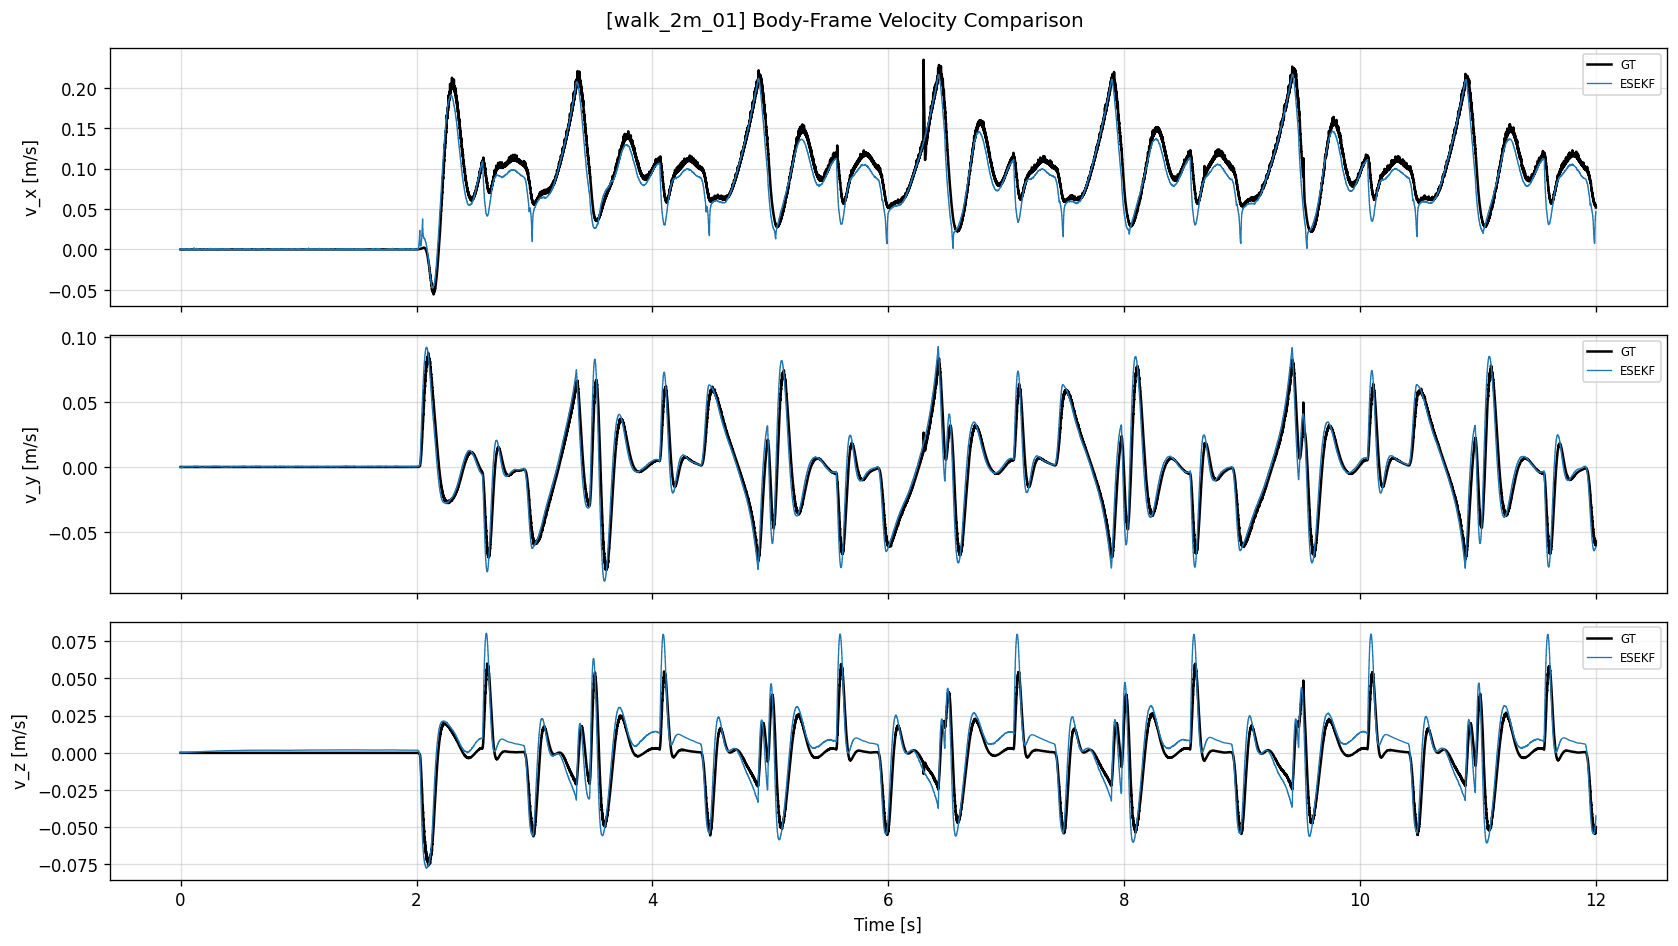

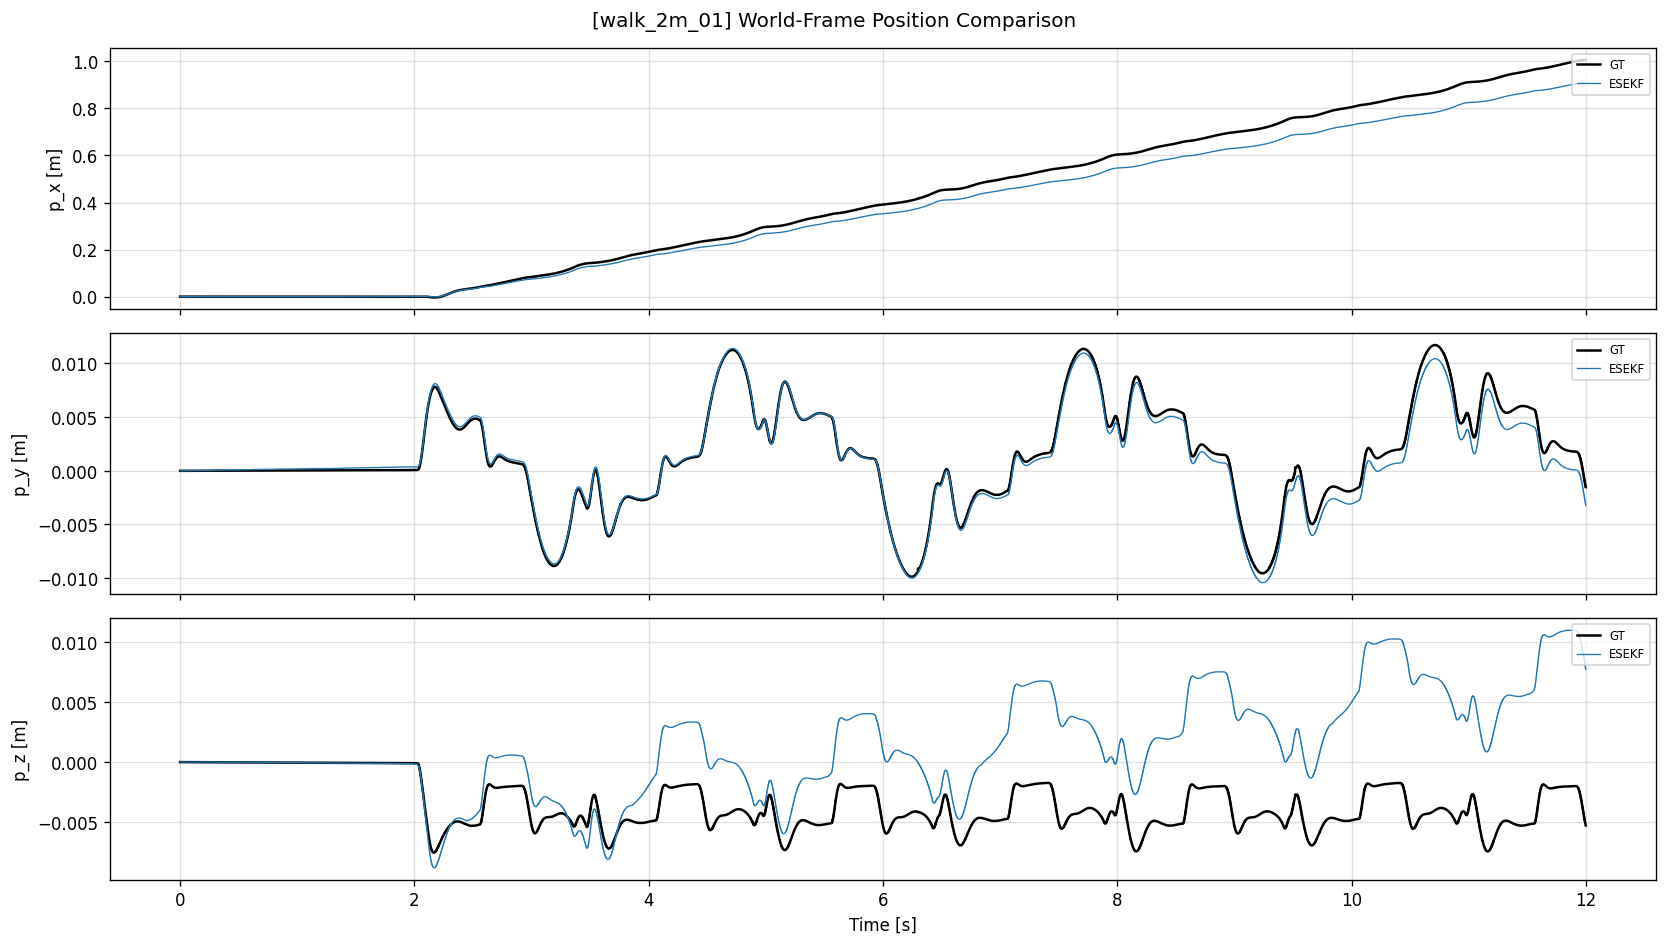

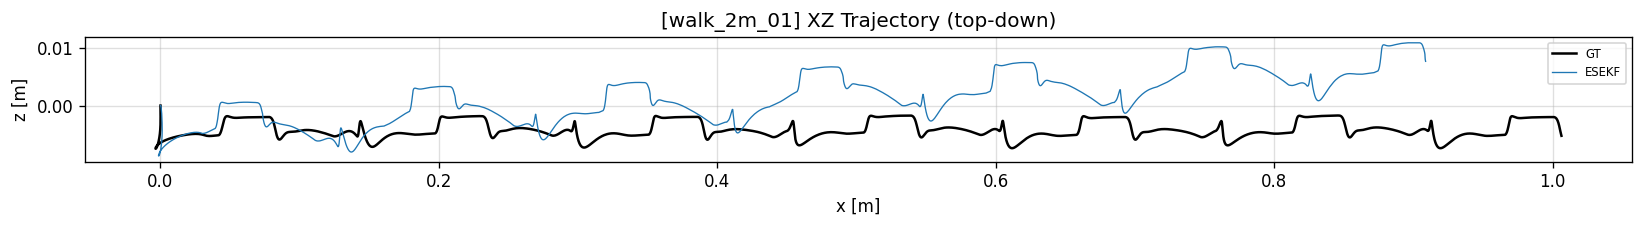


===== [walk_2m_01] Velocity RMSE vs GT (mm/s) =====
Method                      Vx      Vy      Vz
IMU (gyro)               257.9   176.8    68.7
Leg odom                  71.8    21.5    16.4
ESEKF                     14.7    10.0    10.0

===== [walk_2m_01] Position RMSE vs GT (mm) =====
Method                      Px      Py      Pz
IMU (gyro)               980.4   650.8   309.5
Leg odom                 285.5     2.6     2.5
ESEKF                     50.5     0.7     6.3


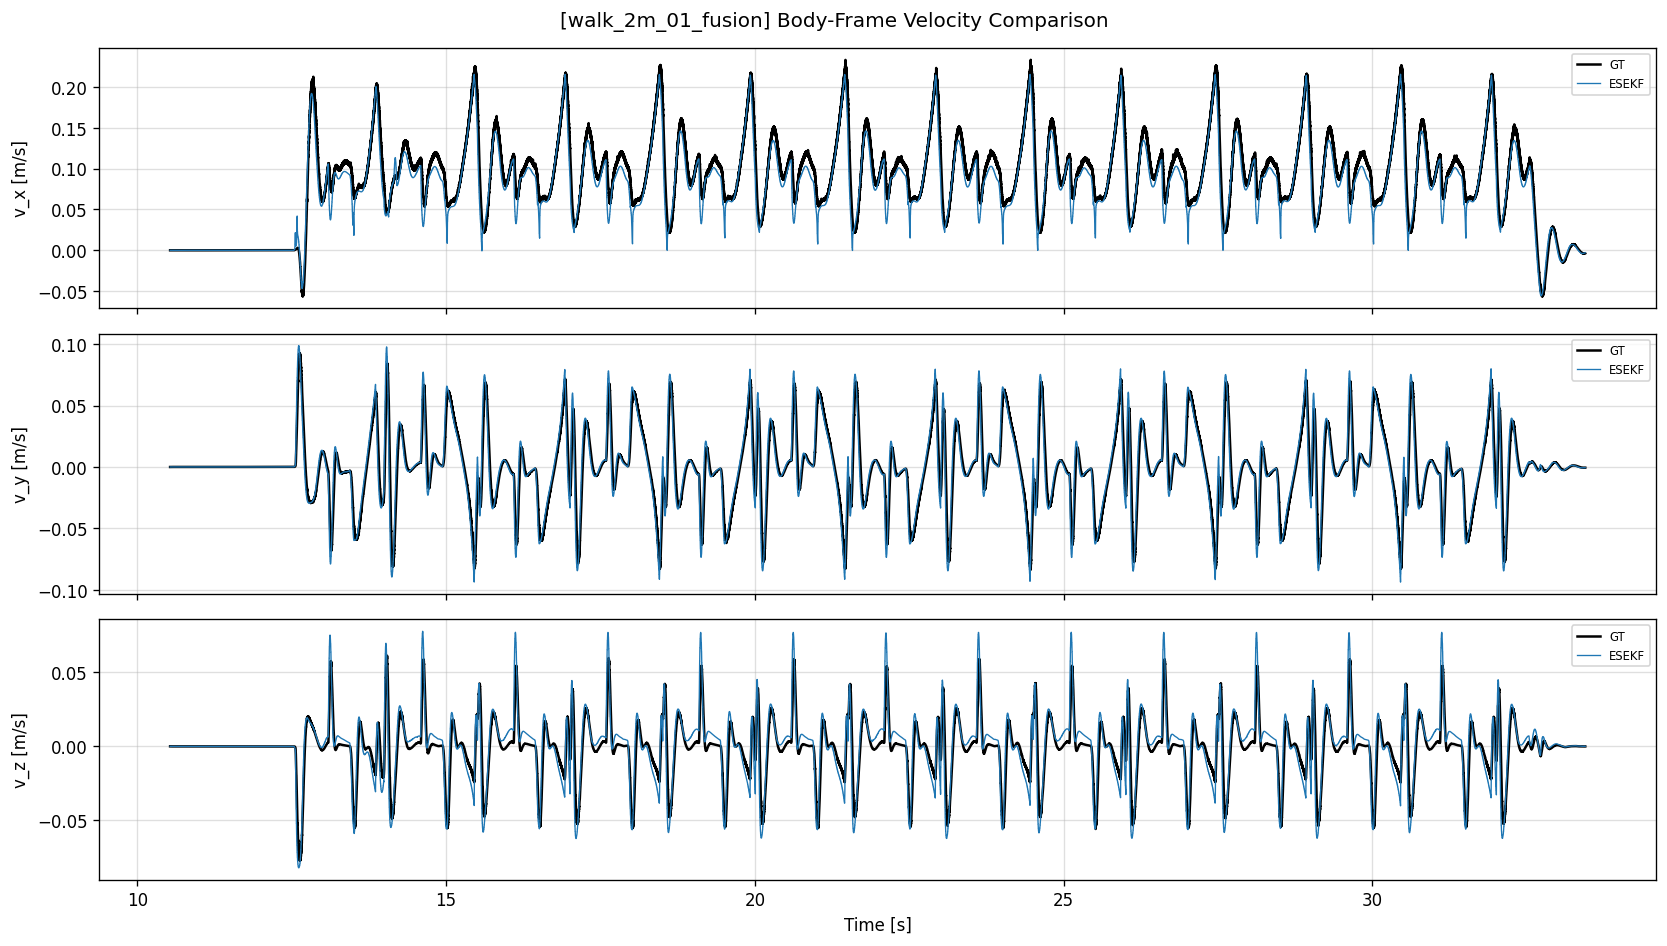

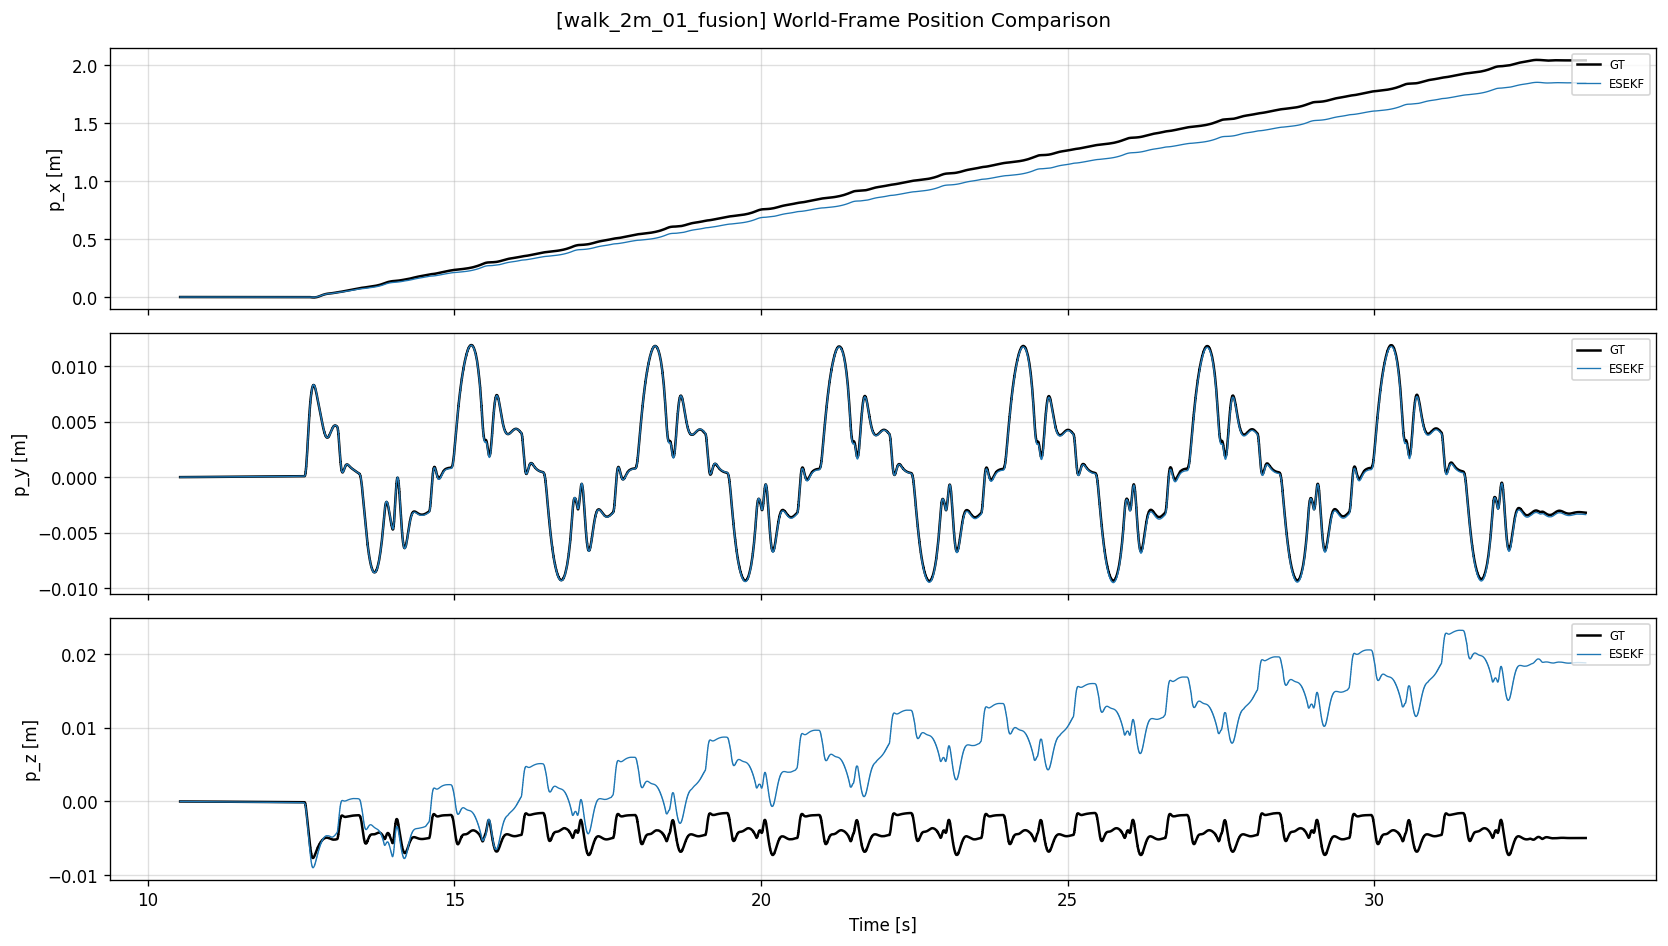

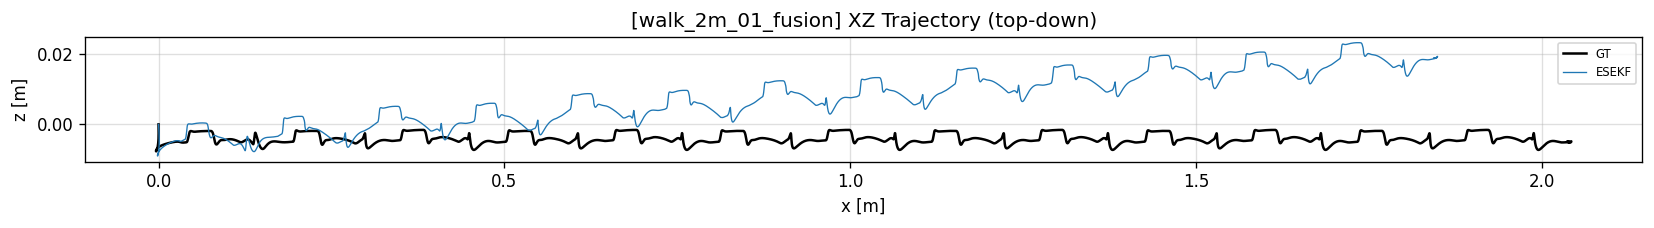


===== [walk_2m_01_fusion] Velocity RMSE vs GT (mm/s) =====
Method                      Vx      Vy      Vz
IMU (gyro)                11.0    11.6     9.7
Leg odom                  74.0    22.5    16.7
ESEKF                     15.7    11.3    10.6

===== [walk_2m_01_fusion] Position RMSE vs GT (mm) =====
Method                      Px      Py      Pz
IMU (gyro)                16.0     3.9     2.1
Leg odom                 634.4     2.5     4.3
ESEKF                    110.9     0.1    13.6


In [6]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

AXES   = ['x', 'y', 'z']
LABELS = {'gt': 'GT', 'imu': 'IMU (gyro)', 'leg': 'Leg odom', 'est': 'ESEKF'}
COLORS = {'gt': 'black', 'imu': 'tab:red', 'leg': 'tab:green', 'est': 'tab:blue'}

for name, D in datasets.items():
    t = D['t']

    # ── Velocity comparison ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'[{name}] Body-Frame Velocity Comparison')
    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, D['gt_vel_b'][:, i],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
        # ax.plot(t, D['imu_vel_b'][:, i], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
        # ax.plot(t, D['leg_vel_b'][:, i], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
        ax.plot(t, D['est_vel_b'][:, i], lw=0.8, color=COLORS['est'], label=LABELS['est'])
        ax.set_ylabel(f'v_{ax_label} [m/s]')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── Position comparison ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'[{name}] World-Frame Position Comparison')
    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, D['gt_pos'][:, i],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
        # ax.plot(t, D['imu_pos'][:, i], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
        # ax.plot(t, D['leg_pos'][:, i], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
        ax.plot(t, D['est_pos'][:, i], lw=0.8, color=COLORS['est'], label=LABELS['est'])
        ax.set_ylabel(f'p_{ax_label} [m]')
        ax.legend(loc='upper right', fontsize=7)
        ax.grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── XZ Trajectory (top-down) ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 2))
    ax.set_title(f'[{name}] XZ Trajectory (top-down)')
    ax.plot(D['gt_pos'][:, 0],  D['gt_pos'][:, 2],  lw=1.5, color=COLORS['gt'],  label=LABELS['gt'])
    # ax.plot(D['imu_pos'][:, 0], D['imu_pos'][:, 2], lw=0.8, color=COLORS['imu'], label=LABELS['imu'])
    # ax.plot(D['leg_pos'][:, 0], D['leg_pos'][:, 2], lw=0.8, color=COLORS['leg'], label=LABELS['leg'])
    ax.plot(D['est_pos'][:, 0], D['est_pos'][:, 2], lw=0.8, color=COLORS['est'], label=LABELS['est'])
    ax.set_xlabel('x [m]');  ax.set_ylabel('z [m]')
    ax.legend(fontsize=7);   ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── RMSE tables ──────────────────────────────────────────────────────────
    methods = {
        'IMU (gyro)': (D['imu_vel_b'], D['imu_pos']),
        'Leg odom':   (D['leg_vel_b'], D['leg_pos']),
        'ESEKF':      (D['est_vel_b'], D['est_pos']),
    }
    print(f'\n===== [{name}] Velocity RMSE vs GT (mm/s) =====')
    print(f'{"Method":<22}{"Vx":>8}{"Vy":>8}{"Vz":>8}')
    for mname, (vel, _) in methods.items():
        err  = (vel - D['gt_vel_b']) * 1e3
        rmse = np.sqrt(np.mean(err**2, axis=0))
        print(f'{mname:<22}{rmse[0]:>8.1f}{rmse[1]:>8.1f}{rmse[2]:>8.1f}')

    print(f'\n===== [{name}] Position RMSE vs GT (mm) =====')
    print(f'{"Method":<22}{"Px":>8}{"Py":>8}{"Pz":>8}')
    for mname, (_, pos) in methods.items():
        err  = (pos - D['gt_pos']) * 1e3
        rmse = np.sqrt(np.mean(err**2, axis=0))
        print(f'{mname:<22}{rmse[0]:>8.1f}{rmse[1]:>8.1f}{rmse[2]:>8.1f}')

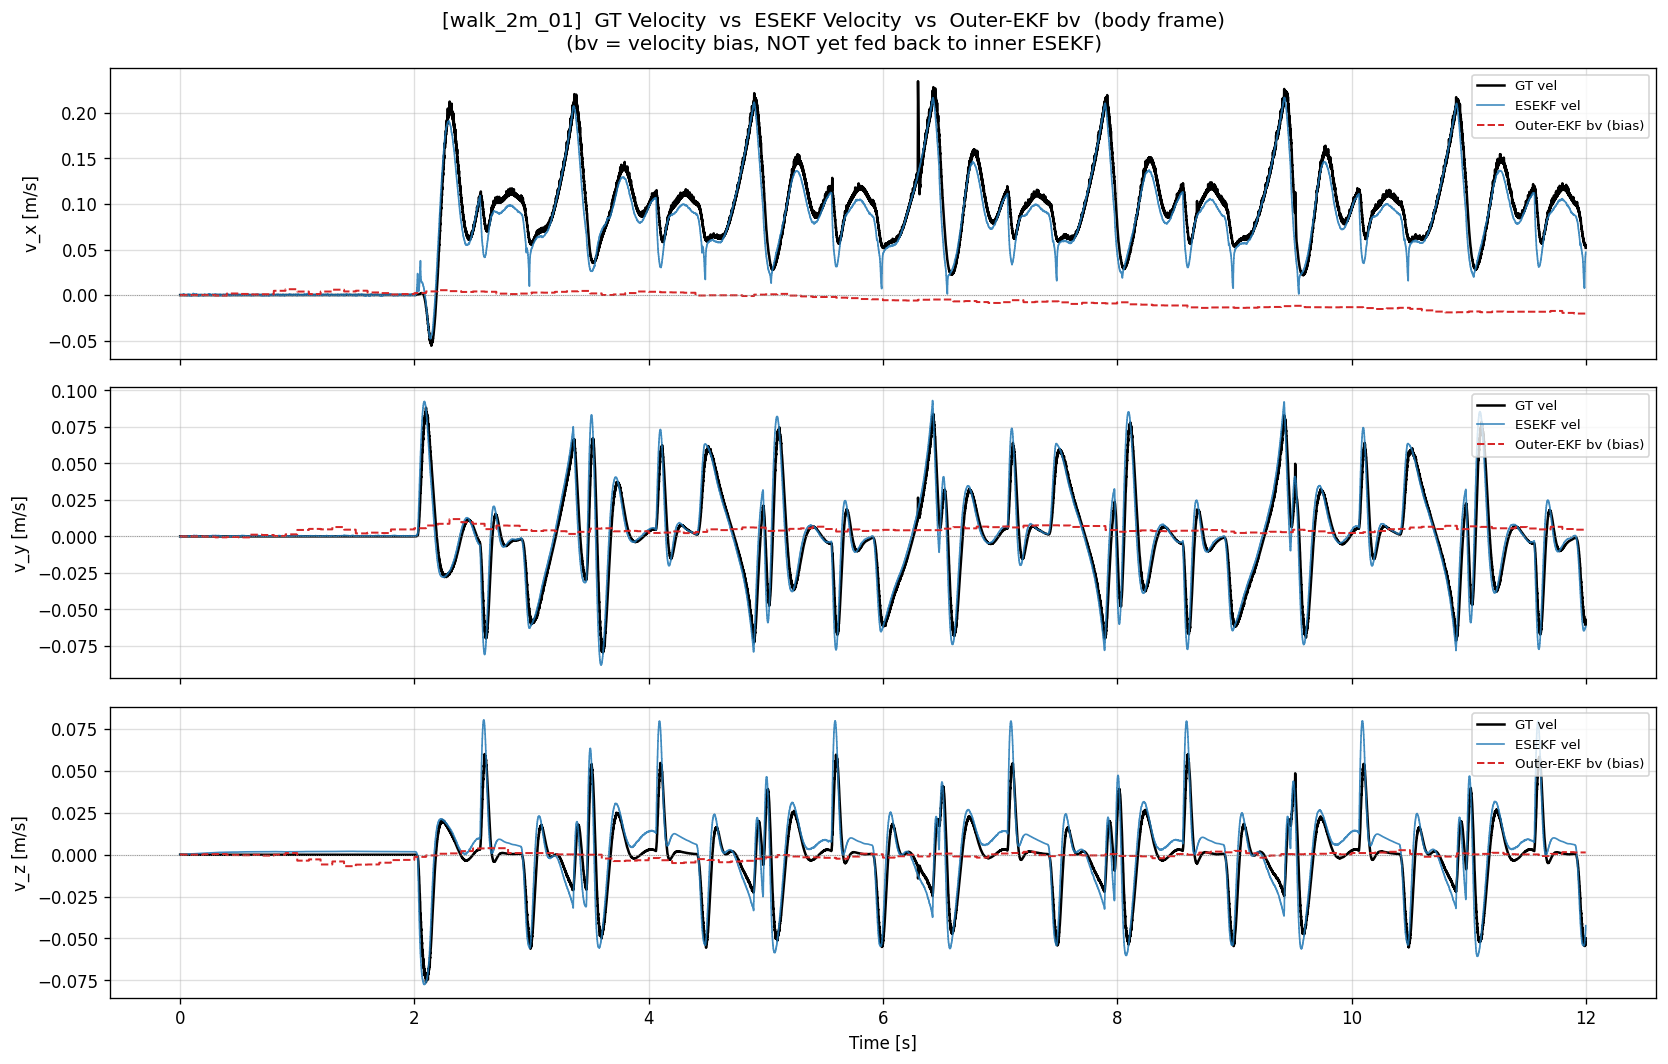

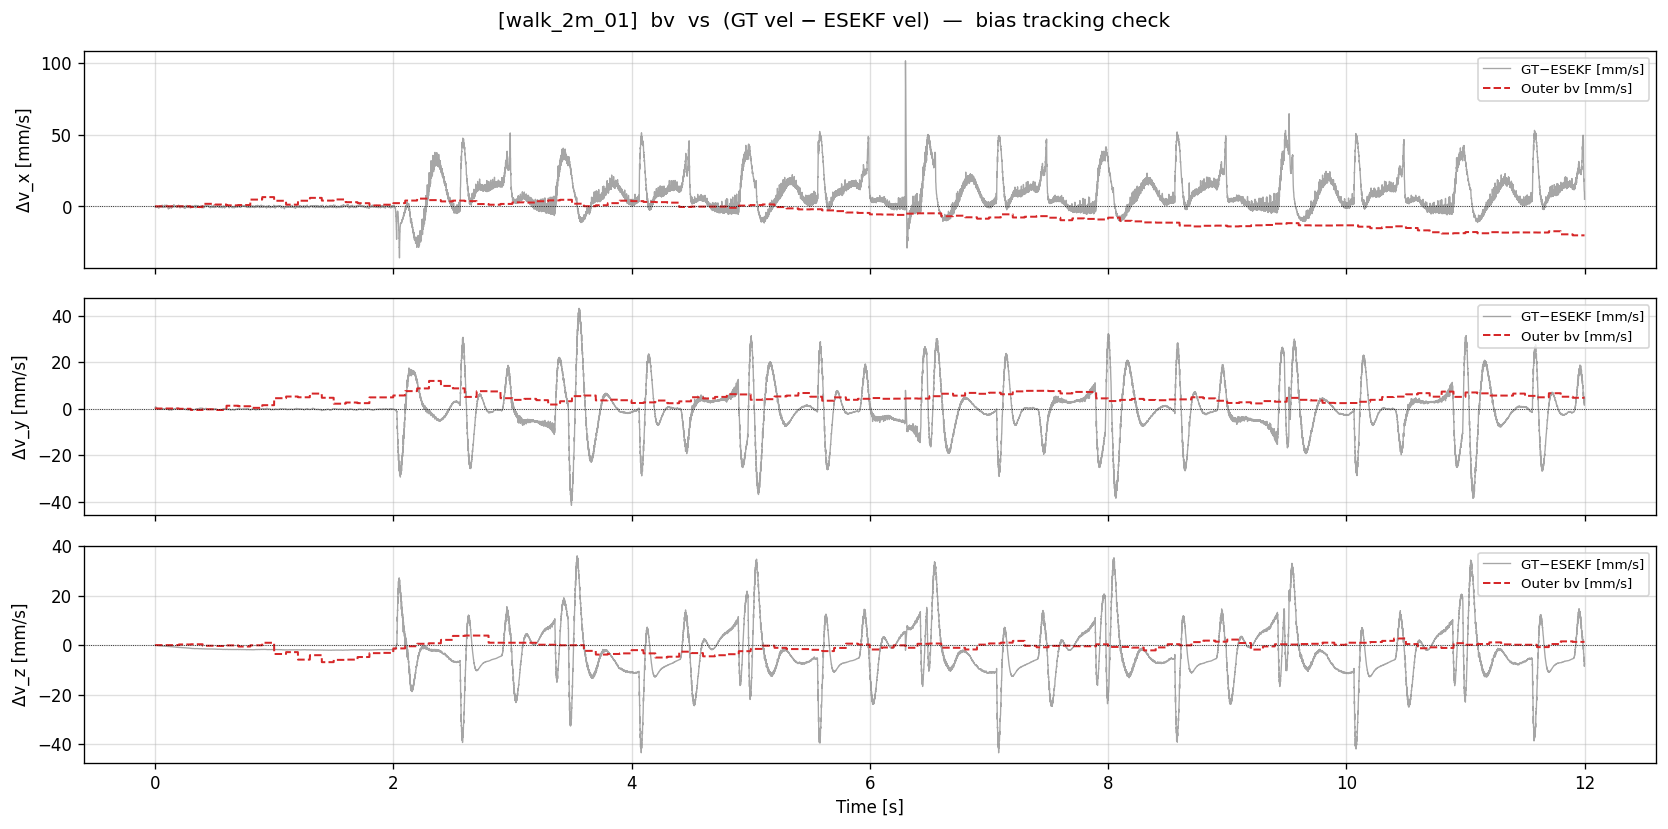


===== [walk_2m_01] Outer-EKF bv Summary =====
  Final bv     : [-0.0203  +0.0046  +0.0013] m/s
  Mean bv (2nd half): [-0.0122  +0.0049  +0.0001] m/s
  Mean GT−ESEKF vel (2nd half): [+0.0097  -0.0009  -0.0032] m/s


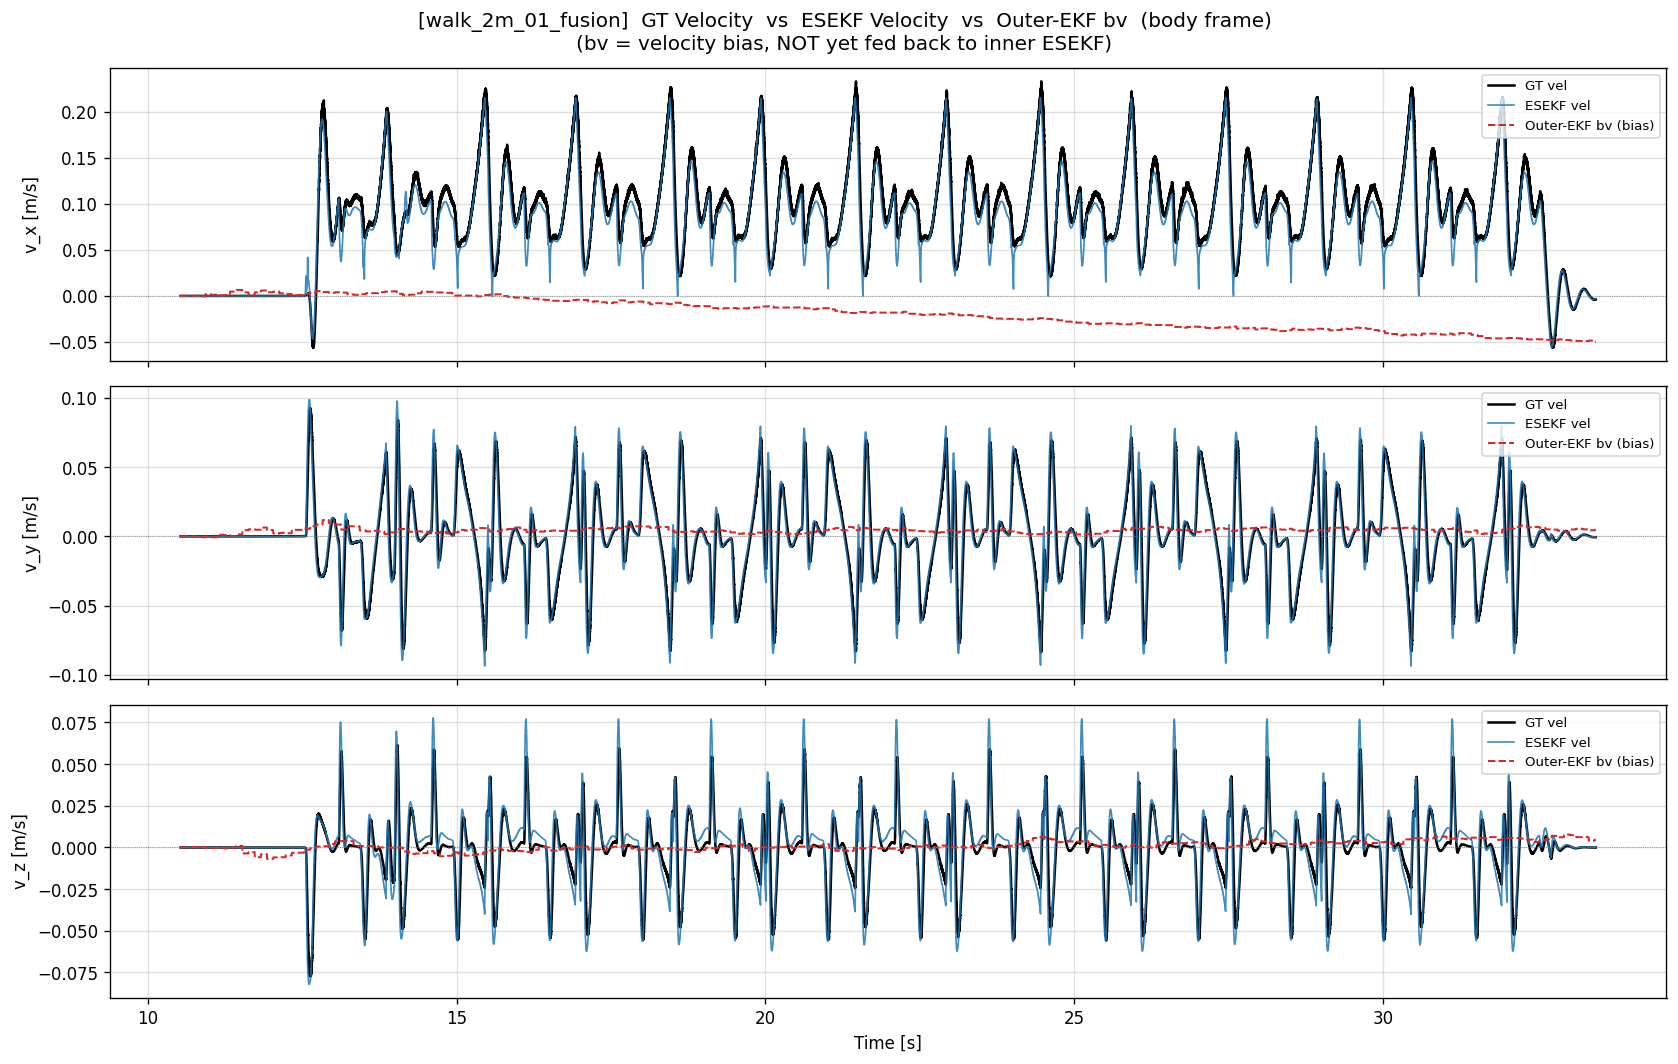

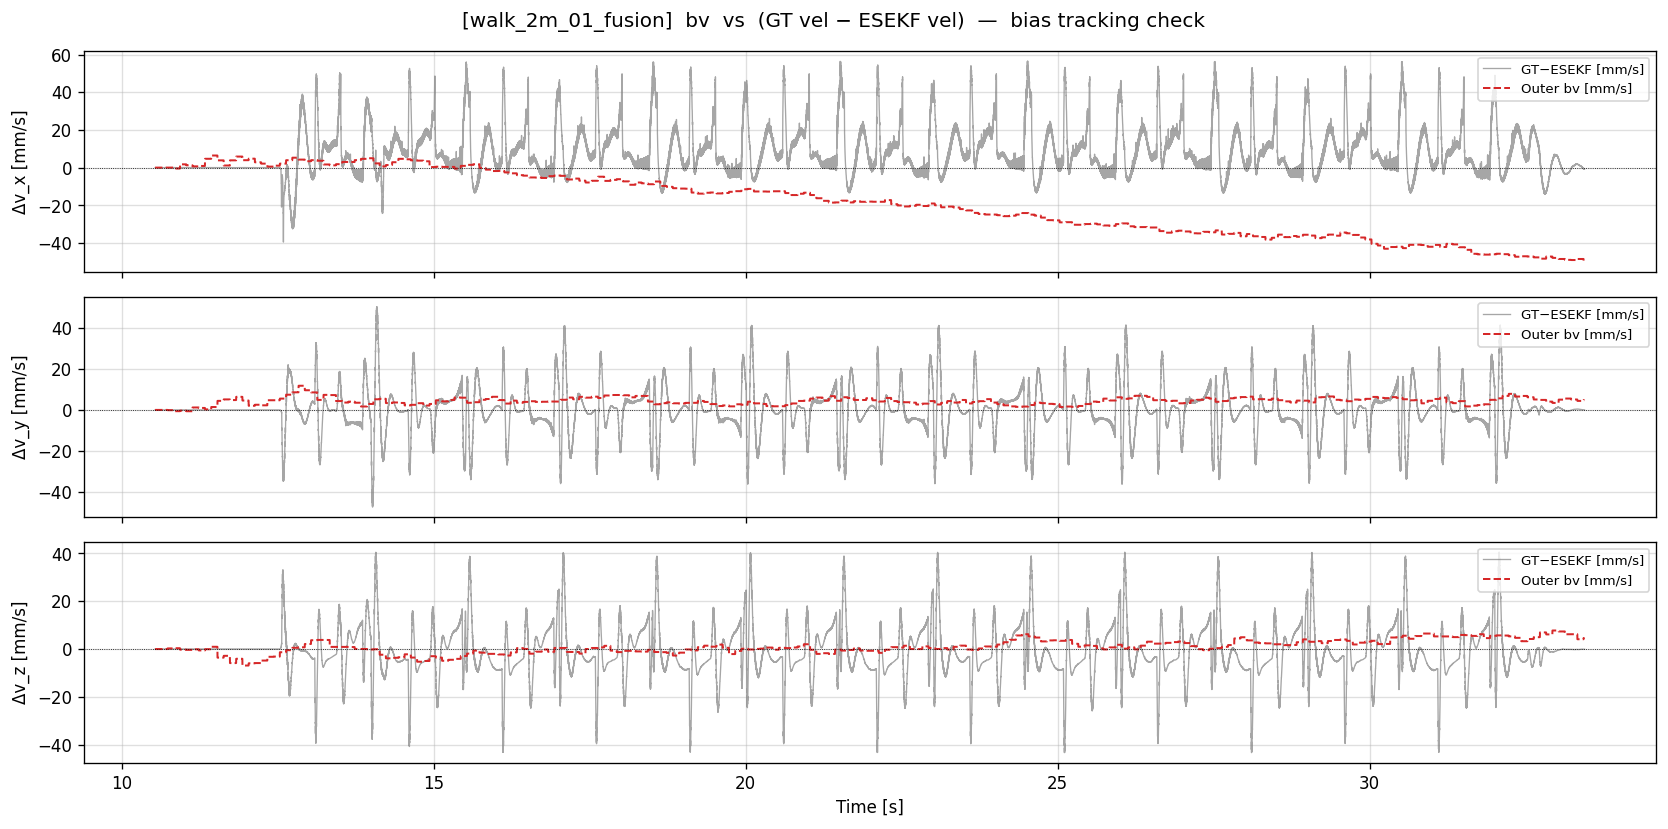


===== [walk_2m_01_fusion] Outer-EKF bv Summary =====
  Final bv     : [-0.0498  +0.0048  +0.0046] m/s
  Mean bv (2nd half): [-0.0341  +0.0045  +0.0029] m/s
  Mean GT−ESEKF vel (2nd half): [+0.0092  +0.0001  -0.0011] m/s


In [7]:

# ── Outer EKF: GT velocity vs ESEKF velocity vs bv (outer EKF) ─────────────
# bv = outer EKF velocity bias estimate (body frame) from walk_2m_01_esekf.csv
# NOTE: bv is NOT yet fed back into inner ESEKF (Phase 3 deferred)

for name, D in datasets.items():
    t   = D['t']
    df  = D['df']

    if 'bv_x' not in df.columns:
        print(f'[{name}] No bv_x column — skipping')
        continue

    bv = df[['bv_x', 'bv_y', 'bv_z']].values       # outer EKF bv estimate
    gt_vel  = D['gt_vel_b']                           # GT body-frame velocity
    est_vel = D['est_vel_b']                          # ESEKF body-frame velocity

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f'[{name}]  GT Velocity  vs  ESEKF Velocity  vs  Outer-EKF bv  (body frame)\n'
                 '(bv = velocity bias, NOT yet fed back to inner ESEKF)', fontsize=12)

    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, gt_vel[:, i],  lw=1.5, color='black',      label='GT vel')
        ax.plot(t, est_vel[:, i], lw=1.0, color='tab:blue',   label='ESEKF vel', alpha=0.85)
        ax.plot(t, bv[:, i],      lw=1.2, color='tab:red',    label='Outer-EKF bv (bias)', linestyle='--')
        ax.axhline(0, color='gray', lw=0.5, linestyle=':')
        ax.set_ylabel(f'v_{ax_label} [m/s]')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── bv vs (GT vel - ESEKF vel): is bv tracking the systematic error? ────
    sys_err = gt_vel - est_vel   # systematic velocity error (body frame)

    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f'[{name}]  bv  vs  (GT vel − ESEKF vel)  —  bias tracking check', fontsize=12)

    for i, ax_label in enumerate(AXES):
        ax = axes[i]
        ax.plot(t, sys_err[:, i] * 1e3, lw=0.8, color='gray',    label='GT−ESEKF [mm/s]', alpha=0.7)
        ax.plot(t, bv[:, i] * 1e3,      lw=1.2, color='tab:red', label='Outer bv [mm/s]', linestyle='--')
        ax.axhline(0, color='k', lw=0.5, linestyle=':')
        ax.set_ylabel(f'Δv_{ax_label} [mm/s]')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    print(f'\n===== [{name}] Outer-EKF bv Summary =====')
    print(f'  Final bv     : [{bv[-1, 0]:+.4f}  {bv[-1, 1]:+.4f}  {bv[-1, 2]:+.4f}] m/s')
    mean_bv = bv[len(bv)//2:].mean(axis=0)   # mean over 2nd half (converged)
    print(f'  Mean bv (2nd half): [{mean_bv[0]:+.4f}  {mean_bv[1]:+.4f}  {mean_bv[2]:+.4f}] m/s')
    mean_err = sys_err[len(sys_err)//2:].mean(axis=0)
    print(f'  Mean GT−ESEKF vel (2nd half): [{mean_err[0]:+.4f}  {mean_err[1]:+.4f}  {mean_err[2]:+.4f}] m/s')


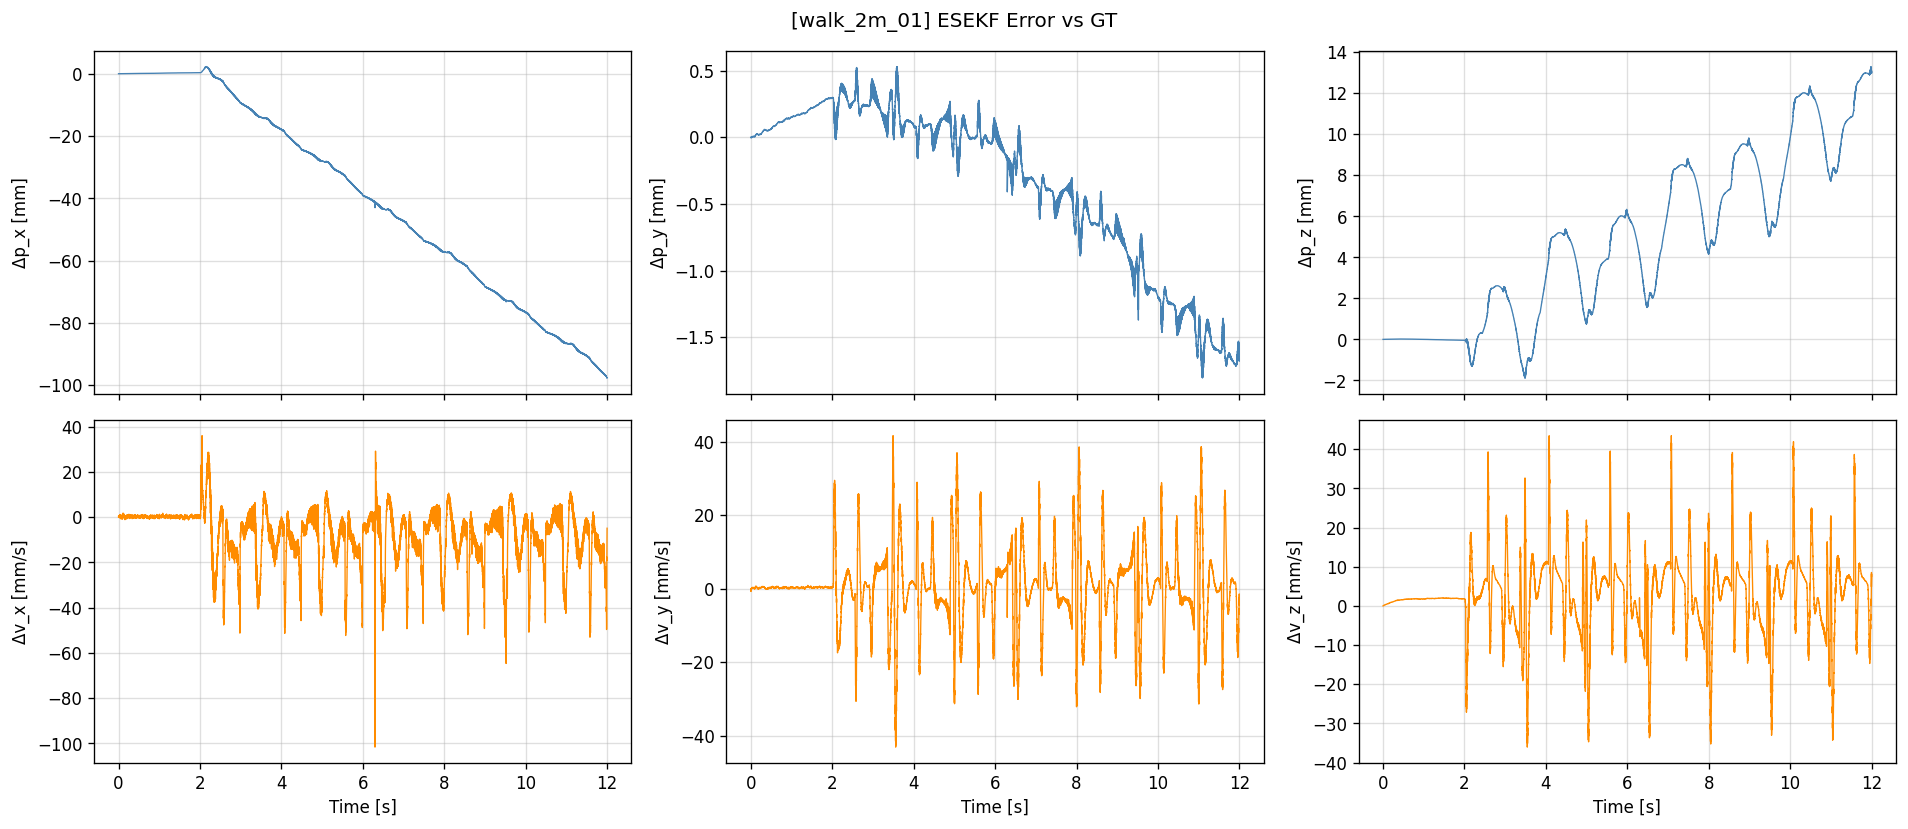

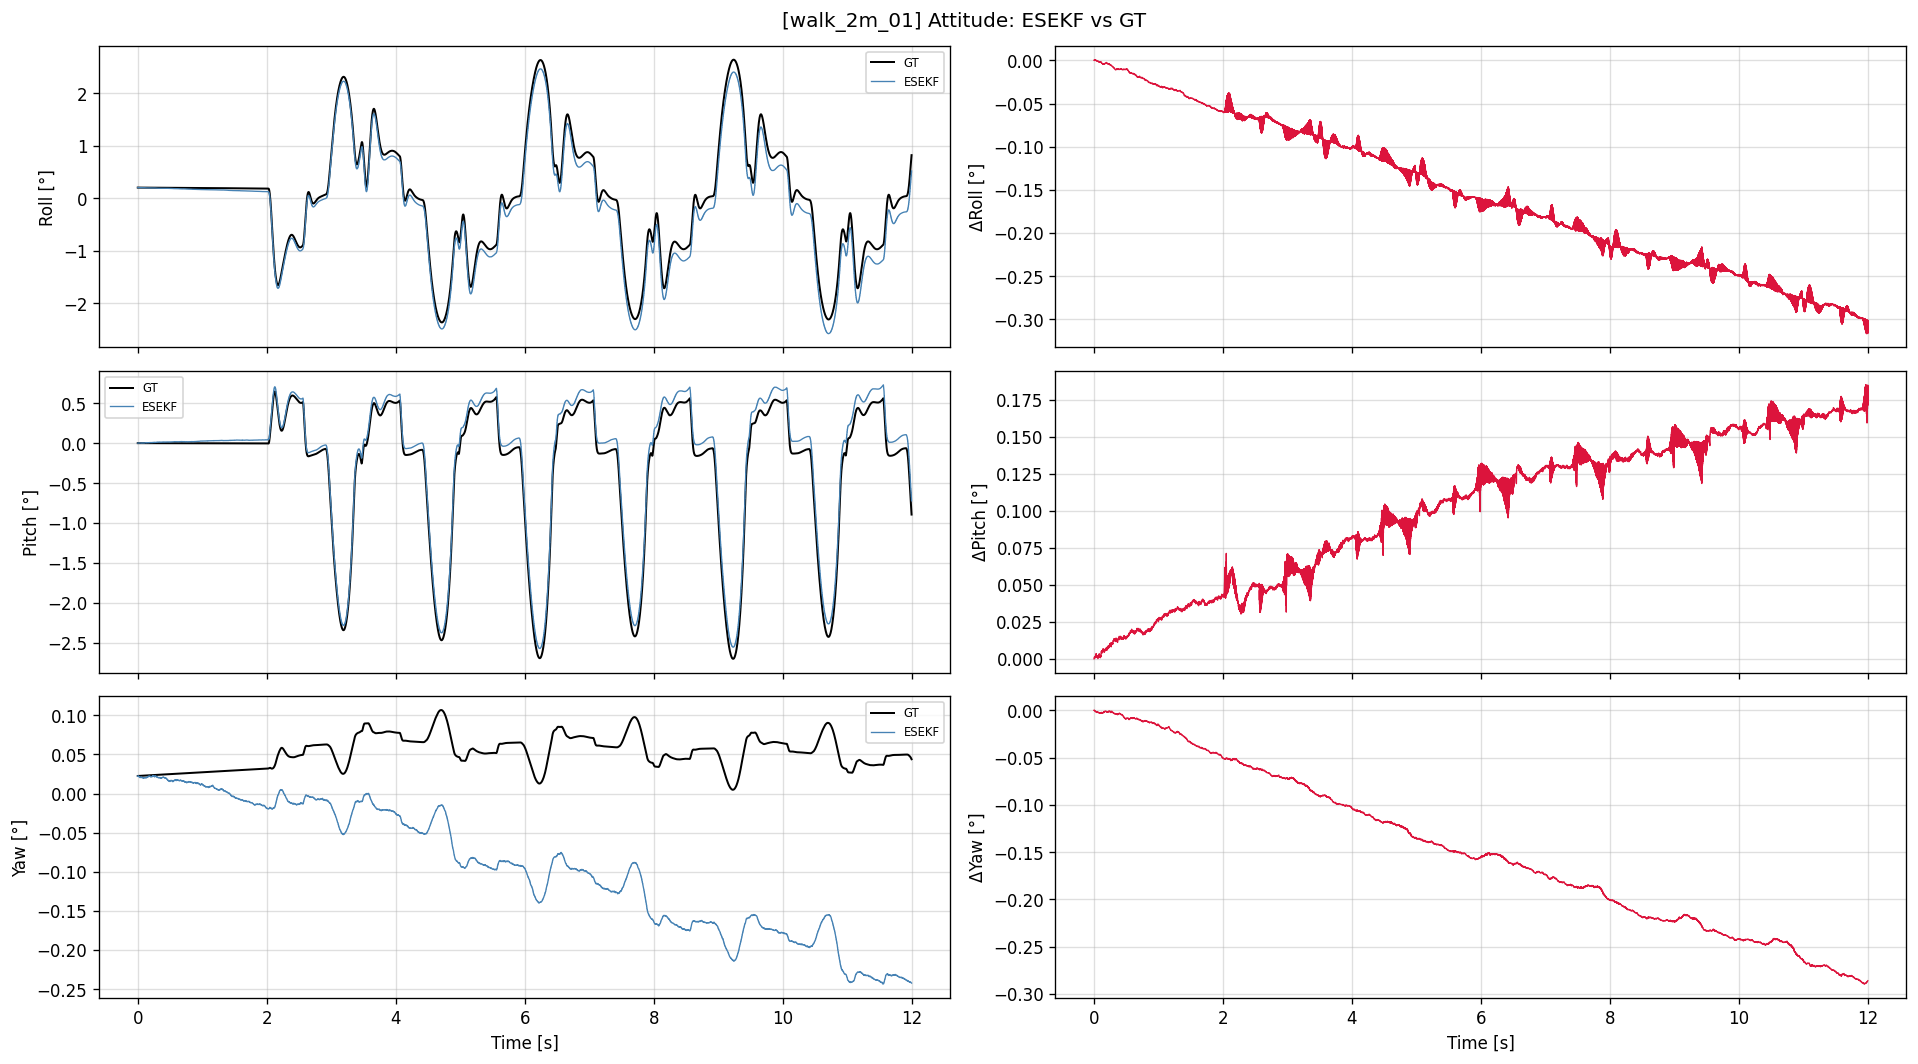

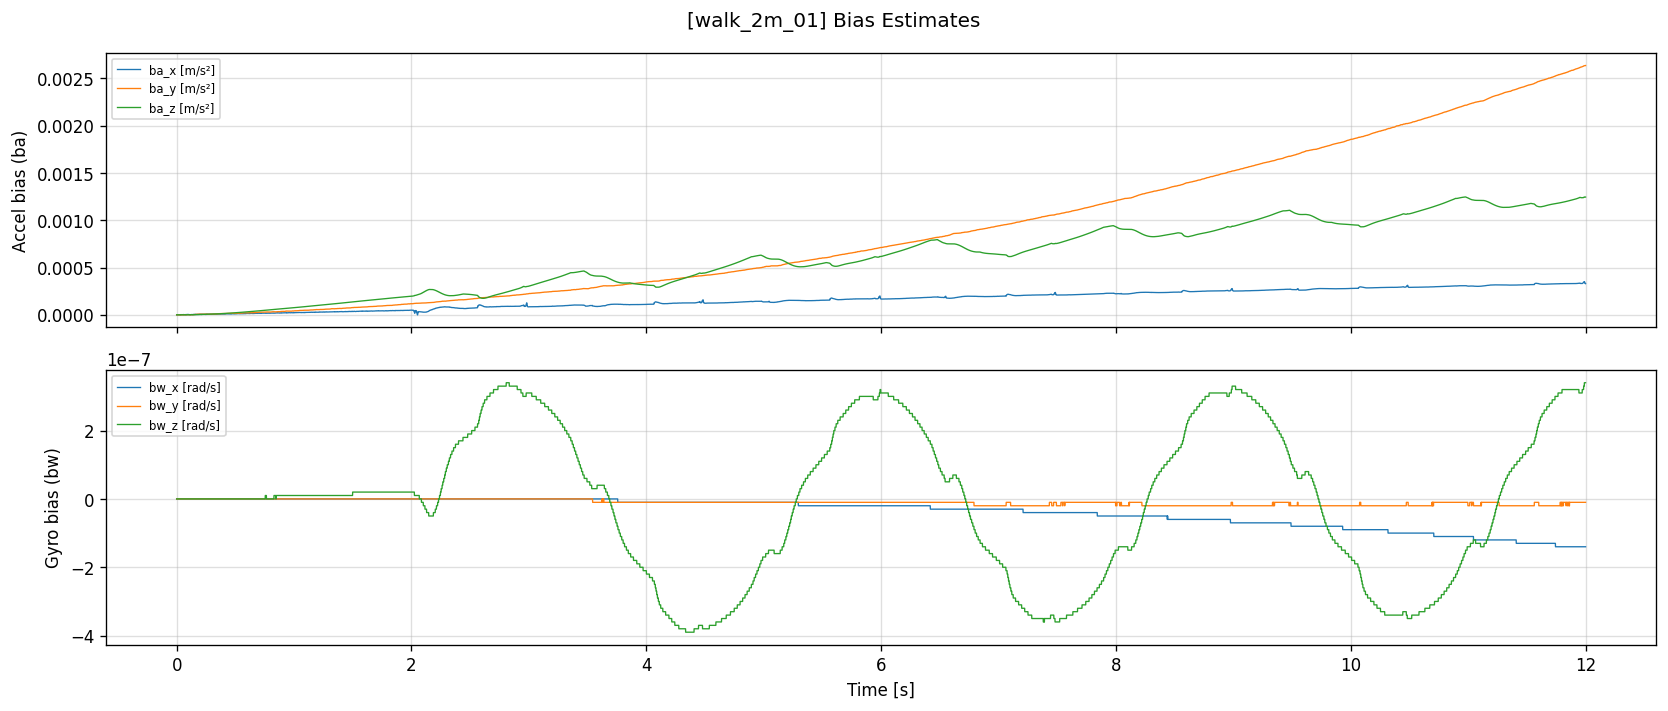

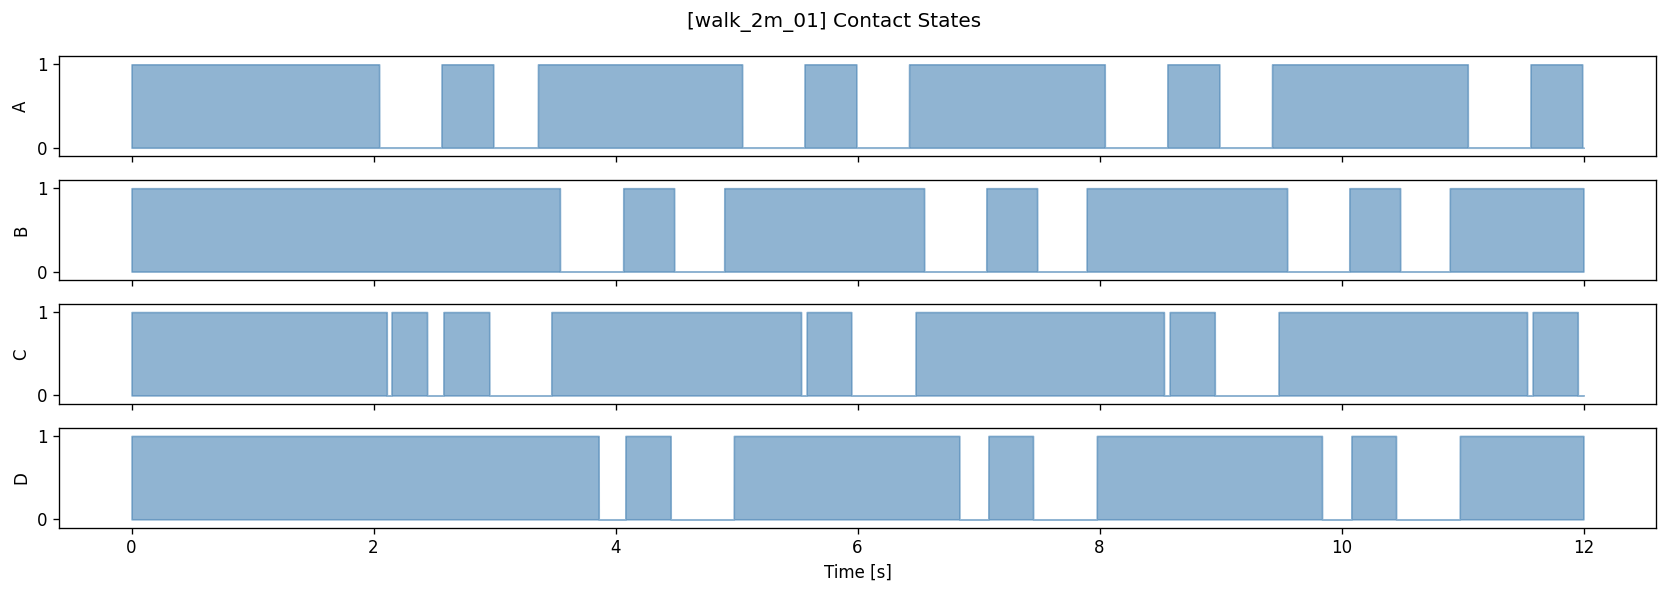

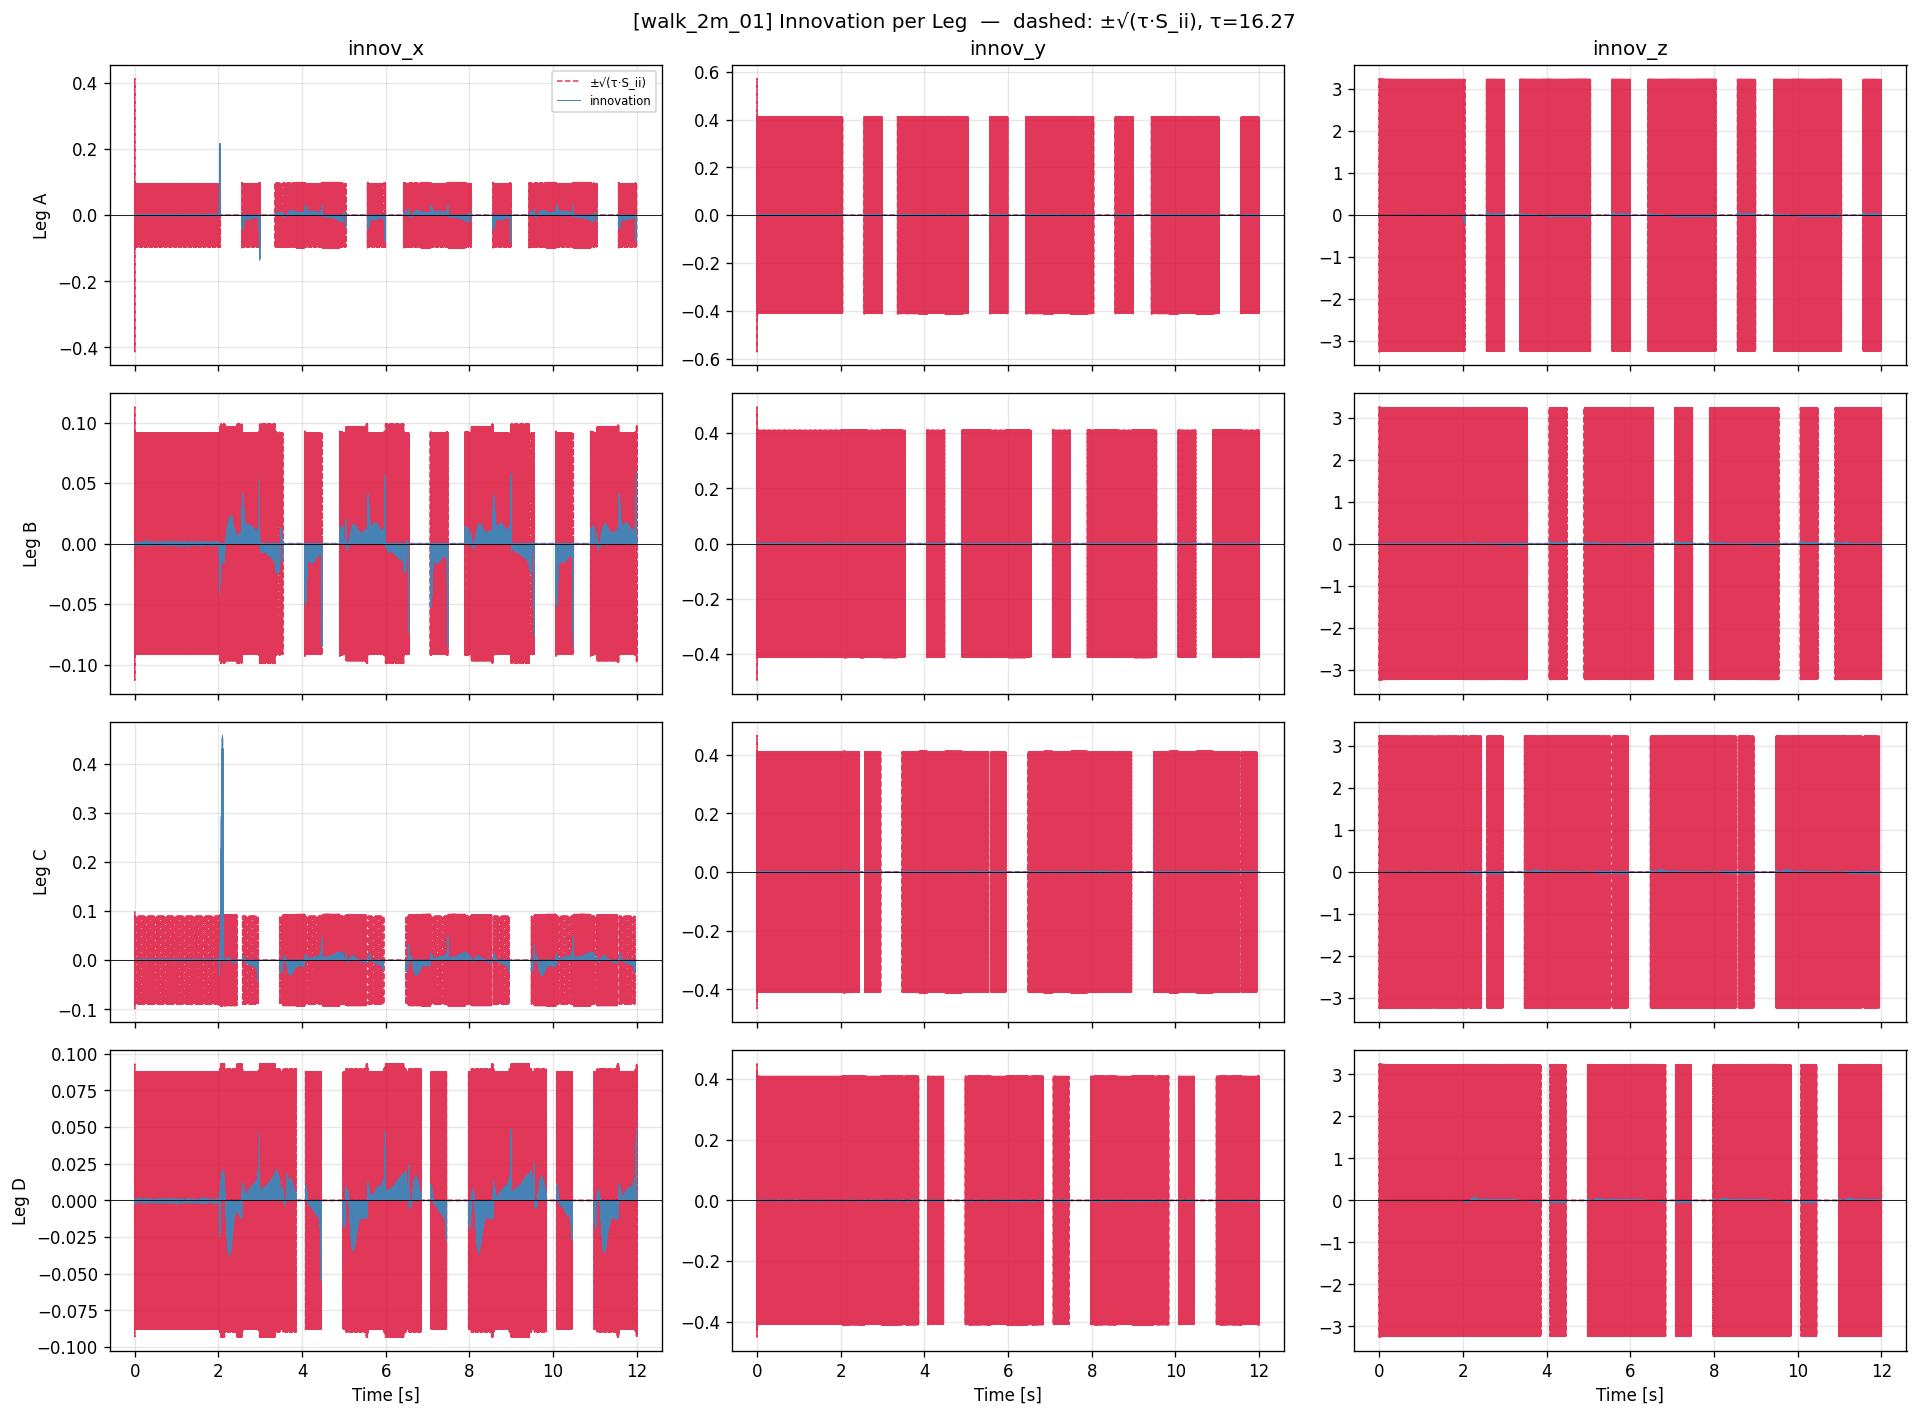

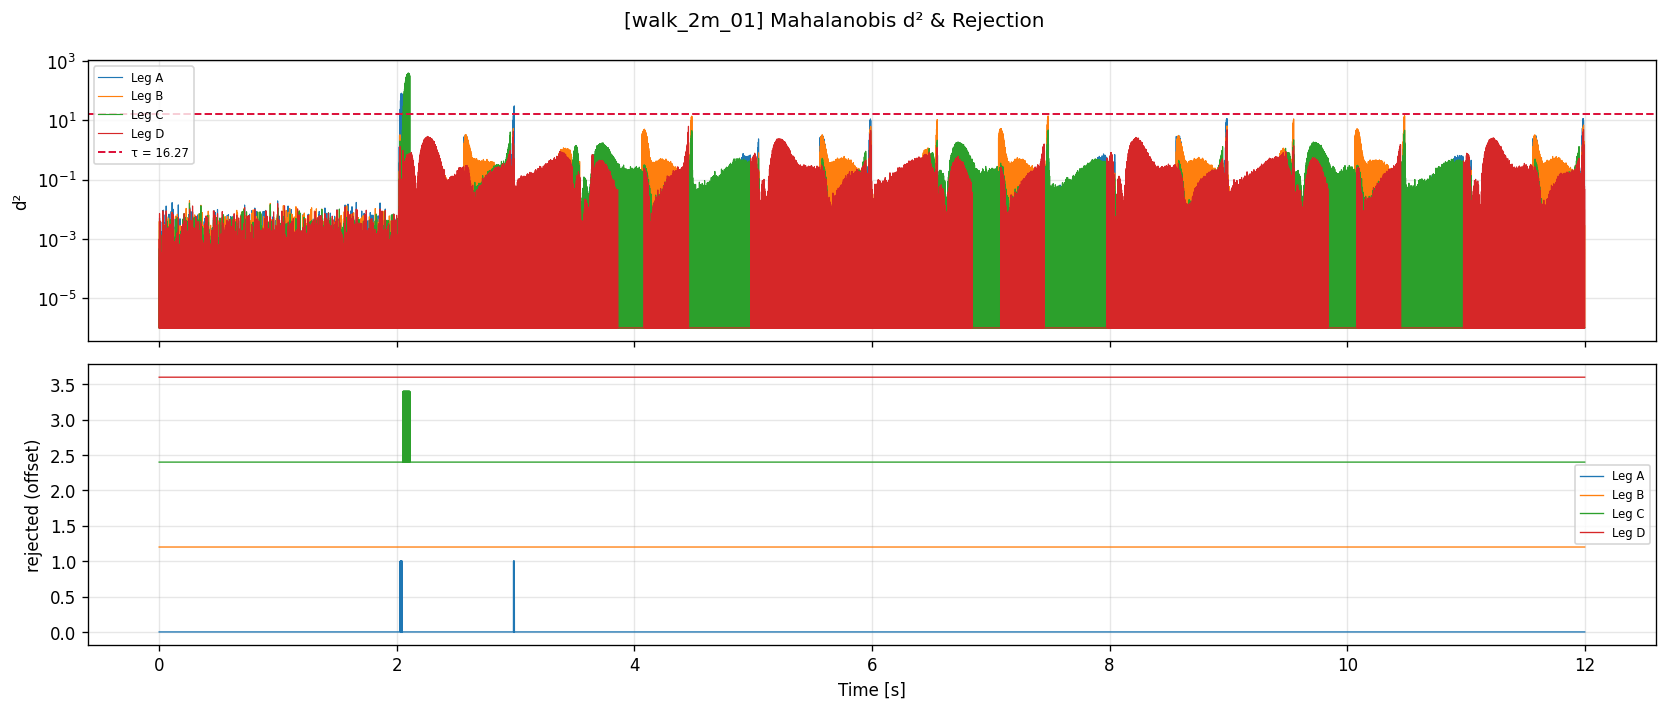

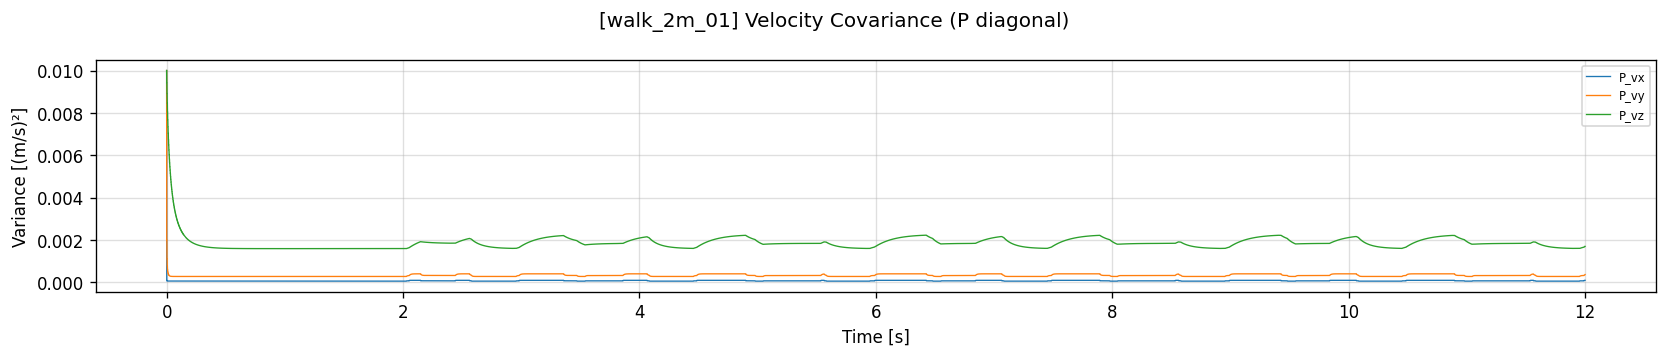

In [5]:
legs = ['a', 'b', 'c', 'd']

for name, D in datasets.items():
    t  = D['t']
    df = D['df']

    # ── Position & velocity error ─────────────────────────────────────────────
    pos_err = (D['est_pos']   - D['gt_pos'])   * 1e3   # mm
    vel_err = (D['est_vel_b'] - D['gt_vel_b']) * 1e3   # mm/s

    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
    fig.suptitle(f'[{name}] ESEKF Error vs GT')
    for i, ax_label in enumerate(AXES):
        axes[0, i].plot(t, pos_err[:, i], lw=0.8, color='steelblue')
        axes[0, i].set_ylabel(f'Δp_{ax_label} [mm]');  axes[0, i].grid(True, alpha=0.4)
        axes[1, i].plot(t, vel_err[:, i], lw=0.8, color='darkorange')
        axes[1, i].set_ylabel(f'Δv_{ax_label} [mm/s]');  axes[1, i].grid(True, alpha=0.4)
        axes[1, i].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Attitude ─────────────────────────────────────────────────────────────
    euler_gt  = quat_to_euler_xyz(df['gt_qw'].values,  df['gt_qx'].values,
                                   df['gt_qy'].values,  df['gt_qz'].values)
    euler_est = quat_to_euler_xyz(df['est_qw'].values, df['est_qx'].values,
                                   df['est_qy'].values, df['est_qz'].values)
    euler_labels = ['Roll', 'Pitch', 'Yaw']

    fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex=True)
    fig.suptitle(f'[{name}] Attitude: ESEKF vs GT')
    for i, elabel in enumerate(euler_labels):
        axes[i, 0].plot(t, euler_gt[:, i],  lw=1.2, color='black',     label='GT')
        axes[i, 0].plot(t, euler_est[:, i], lw=0.8, color='steelblue', label='ESEKF')
        axes[i, 0].set_ylabel(f'{elabel} [°]')
        axes[i, 0].legend(fontsize=7);  axes[i, 0].grid(True, alpha=0.4)
        delta = euler_est[:, i] - euler_gt[:, i]
        axes[i, 1].plot(t, delta, lw=0.8, color='crimson')
        axes[i, 1].set_ylabel(f'Δ{elabel} [°]');  axes[i, 1].grid(True, alpha=0.4)
    axes[2, 0].set_xlabel('Time [s]');  axes[2, 1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Biases ────────────────────────────────────────────────────────────────
    # Note: ESEKF state has ba (accel bias) and bw (gyro bias) only — no bv.
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'[{name}] Bias Estimates')
    for ax_label in AXES:
        axes[0].plot(t, df[f'ba_{ax_label}'].values, lw=0.8, label=f'ba_{ax_label} [m/s²]')
    axes[0].set_ylabel('Accel bias (ba)');  axes[0].legend(fontsize=7);  axes[0].grid(True, alpha=0.4)
    for ax_label in AXES:
        axes[1].plot(t, df[f'bw_{ax_label}'].values, lw=0.8, label=f'bw_{ax_label} [rad/s]')
    axes[1].set_ylabel('Gyro bias (bw)');  axes[1].legend(fontsize=7);  axes[1].grid(True, alpha=0.4)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Contact states ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(14, 5), sharex=True)
    fig.suptitle(f'[{name}] Contact States')
    for i, leg in enumerate(legs):
        c = D['contacts'][:, i].astype(float)
        axes[i].fill_between(t, 0, c, alpha=0.6, color='steelblue')
        axes[i].set_ylim(-0.1, 1.1);  axes[i].set_ylabel(leg.upper())
        axes[i].set_yticks([0, 1]);   axes[i].grid(False)
    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Innovation ± Mahalanobis threshold ───────────────────────────────────
    # Per-axis threshold: |innov_i| = sqrt(τ · S_ii)  from D² = Σ innov²/S_ii ≤ τ
    inax  = ['x', 'y', 'z']
    s_col = {'x': 'S_xx', 'y': 'S_yy', 'z': 'S_zz'}
    fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)
    fig.suptitle(f'[{name}] Innovation per Leg  —  dashed: ±√(τ·S_ii), τ={MAHA_THRESH}')
    for col_j, iax in enumerate(inax):
        axes[0, col_j].set_title(f'innov_{iax}')
    for row_i, leg in enumerate(legs):
        for col_j, iax in enumerate(inax):
            ax     = axes[row_i, col_j]
            innov  = df[f'innov_{iax}_{leg}'].values
            s_diag = df[f'{s_col[iax]}_{leg}'].values
            thresh = np.sqrt(MAHA_THRESH * np.abs(s_diag))
            lbl = '±√(τ·S_ii)' if (row_i == 0 and col_j == 0) else None
            ax.plot(t, +thresh, lw=0.9, color='crimson', ls='--', alpha=0.85, label=lbl)
            ax.plot(t, -thresh, lw=0.9, color='crimson', ls='--', alpha=0.85)
            ax.plot(t, innov,   lw=0.6, color='steelblue',
                    label='innovation' if (row_i == 0 and col_j == 0) else None)
            ax.axhline(0, color='k', lw=0.5)
            if col_j == 0:
                ax.set_ylabel(f'Leg {leg.upper()}')
            if row_i == 0 and col_j == 0:
                ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
        if row_i == 3:
            for col_j in range(3):
                axes[row_i, col_j].set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Mahalanobis d² & rejection ────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'[{name}] Mahalanobis d² & Rejection')
    ax1, ax2 = axes
    for leg in legs:
        d2 = df[f'd2_{leg}'].values.clip(1e-6)
        ax1.plot(t, d2, lw=0.7, label=f'Leg {leg.upper()}')
    ax1.axhline(MAHA_THRESH, color='crimson', ls='--', lw=1.2,
                label=f'τ = {MAHA_THRESH}')
    ax1.set_yscale('log');  ax1.set_ylabel('d²')
    ax1.legend(fontsize=7);  ax1.grid(True, alpha=0.3, which='both')
    for i, leg in enumerate(legs):
        rej = df[f'rejected_{leg}'].values.astype(float)
        ax2.plot(t, rej + i * 1.2, lw=0.8, label=f'Leg {leg.upper()}')
    ax2.set_ylabel('rejected (offset)');  ax2.legend(fontsize=7);  ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Time [s]')
    plt.tight_layout();  plt.show()

    # ── Velocity covariance ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 3))
    fig.suptitle(f'[{name}] Velocity Covariance (P diagonal)')
    for ax_label in AXES:
        ax.plot(t, df[f'P_v{ax_label}'].values, lw=0.8, label=f'P_v{ax_label}')
    ax.set_ylabel('Variance [(m/s)²]');  ax.set_xlabel('Time [s]')
    ax.legend(fontsize=7);  ax.grid(True, alpha=0.4)
    plt.tight_layout();  plt.show()


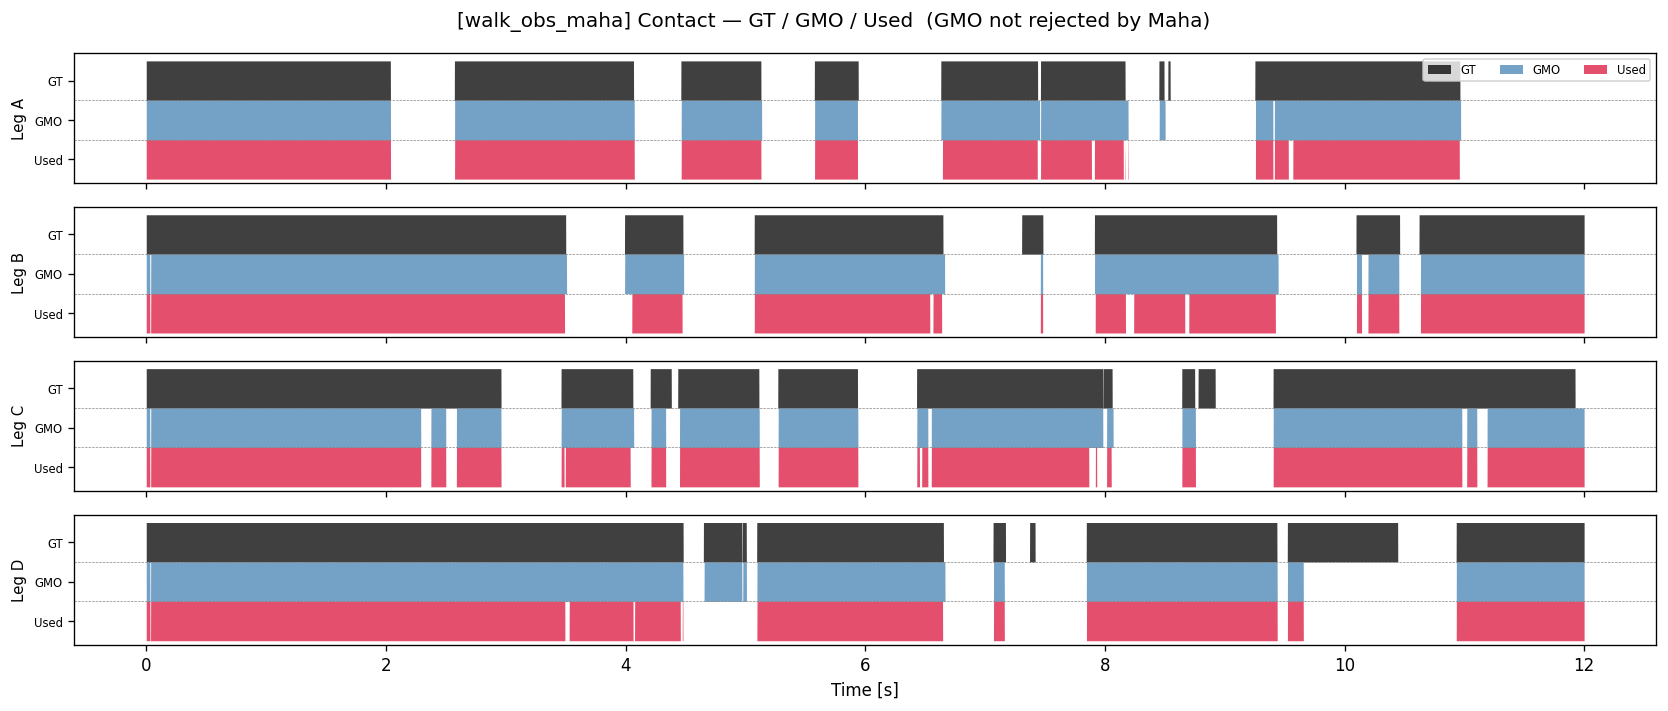

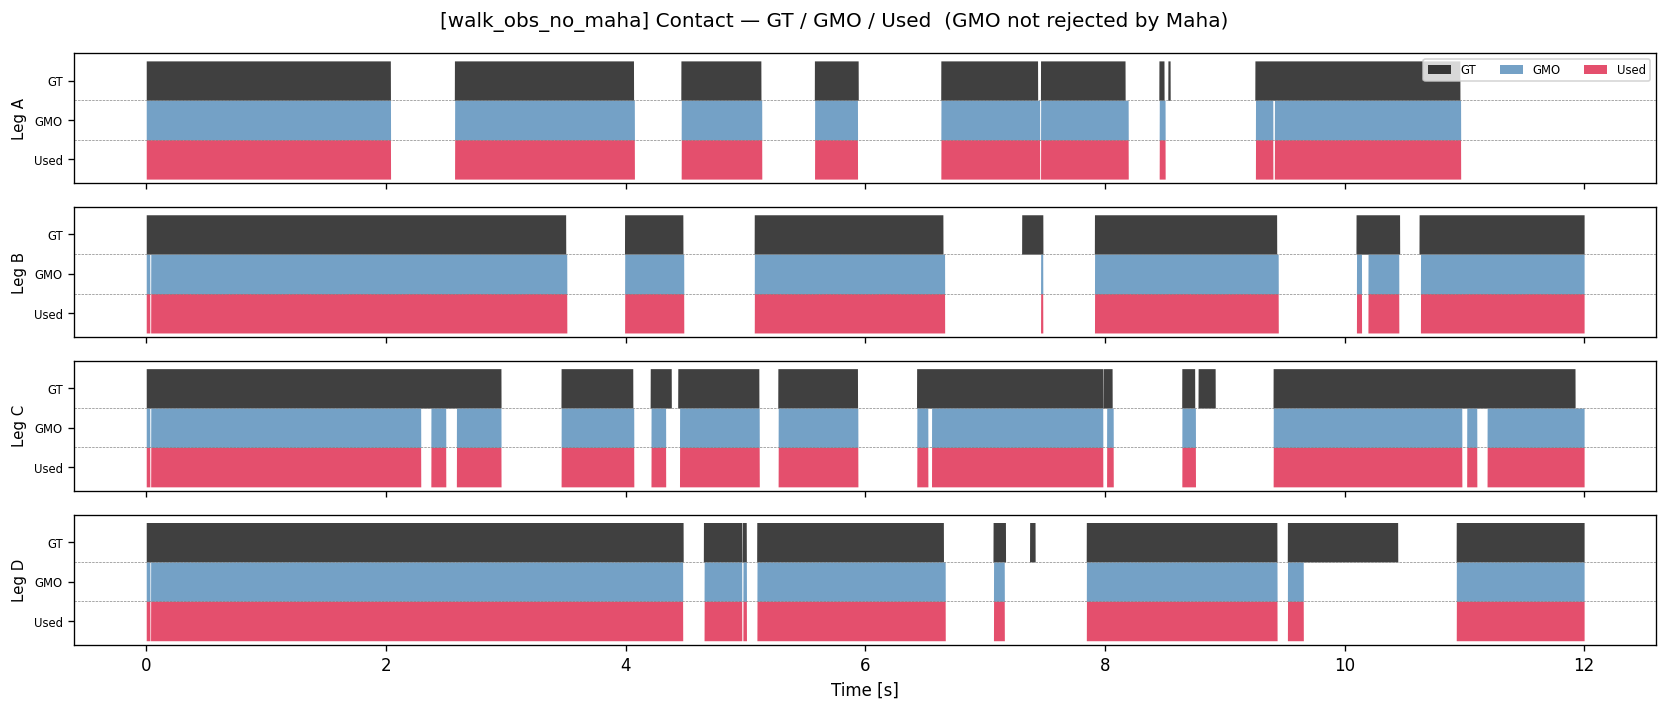

In [40]:
import re

for name, D in datasets.items():
    t   = D['t']
    df  = D['df']
    N   = len(t)

    # ── Load GT contact CSV ─────────────────────────────────────────────────
    # Derive GT csv: strip _maha / _no_maha suffix  (e.g. walk_obs_maha → walk_obs.csv)
    base    = re.sub(r'_(no_maha|maha)$', '', name)
    gt_path = OUTPUT_DIR / f'{base}.csv'
    if not gt_path.exists():
        print(f'[{name}] GT CSV not found: {gt_path}  — skipping')
        continue
    df_gt = pd.read_csv(gt_path).iloc[:N].reset_index(drop=True)

    # Per-leg GT contact  (sim_contact_state_a/b/c/d)
    gt_c = np.column_stack([df_gt[f'sim_contact_state_{leg}'].values
                             for leg in legs]).astype(float)   # (N, 4)

    # GMO contact  (contact_a/b/c/d  from ESEKF csv)
    gmo_c = D['contacts'].astype(float)                        # (N, 4)

    # Used = GMO in contact AND not rejected by Mahalanobis
    rej    = np.column_stack([df[f'rejected_{leg}'].values
                               for leg in legs]).astype(bool)
    used_c = (gmo_c.astype(bool) & ~rej).astype(float)        # (N, 4)

    # ── Plot ────────────────────────────────────────────────────────────────
    LEG_LABELS = ['A', 'B', 'C', 'D']
    C = {'gt': 'black', 'gmo': 'steelblue', 'used': 'crimson'}

    fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'[{name}] Contact — GT / GMO / Used  (GMO not rejected by Maha)')

    for i, (ax, lbl) in enumerate(zip(axes, LEG_LABELS)):
        kw = dict(alpha=0.75, lw=0)
        ax.fill_between(t, 2.0, 2.0 + gt_c[:, i],   **kw, color=C['gt'],
                        label='GT'   if i == 0 else None)
        ax.fill_between(t, 1.0, 1.0 + gmo_c[:, i],  **kw, color=C['gmo'],
                        label='GMO'  if i == 0 else None)
        ax.fill_between(t, 0.0, 0.0 + used_c[:, i], **kw, color=C['used'],
                        label='Used' if i == 0 else None)
        ax.set_ylim(-0.1, 3.2)
        ax.set_yticks([0.5, 1.5, 2.5])
        ax.set_yticklabels(['Used', 'GMO', 'GT'], fontsize=7)
        ax.set_ylabel(f'Leg {lbl}', fontsize=9)
        ax.axhline(1.0, color='gray', lw=0.4, ls='--')
        ax.axhline(2.0, color='gray', lw=0.4, ls='--')
        ax.grid(False)
        if i == 0:
            ax.legend(loc='upper right', fontsize=7, ncol=3)

    axes[-1].set_xlabel('Time [s]')
    plt.tight_layout()
    plt.show()


# Online vs Offline Pipeline Comparison\n\nThis section compares:\n- **Offline pipeline**: `offline_test` run on `online_test_3_raw.csv` (bag data processed by the same C++ ESEKF stack) → `output_data/online_test_3_raw_esekf.csv`\n- **Online pipeline**: `/ekf/*` topics recorded directly in `bag/online_test_3` during live execution\n\nBoth use identical sensor data (same bag), so any difference is due to algorithmic divergence (e.g., timestamp handling, callback timing, topic queuing).

In [6]:
# ── Cell A: Load offline CSV + read online /ekf/* from REPLAY bag ──────────
# Replay bag = online_test_3 data played back through the FIXED online node
# (dt uses raw imu.header.stamp sec/nsec, same as offline pipeline)
import os, sys
import numpy as np
import pandas as pd
import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

# ── Paths (adjust WS_ROOT if needed) ──────────────────────────────────────
WS_ROOT = '/home/hiho817/corgi_ws/corgi_ros2_ws'
offline_csv_path = os.path.join(WS_ROOT, 'output_data', 'online_test_3_raw_esekf.csv')
# Use replay bag (fixed node) — NOT the original online_test_3 bag
bag_path         = os.path.join(WS_ROOT, 'bag', 'online_test_3_replay')

print(f"Offline CSV : {offline_csv_path}")
print(f"Bag path    : {bag_path}")

# ── Load offline ESEKF result ───────────────────────────────────────────────
df_off = pd.read_csv(offline_csv_path)
print(f"Offline rows: {len(df_off)}")

# ── Read online /ekf/* from replay bag ─────────────────────────────────────
storage_options = rosbag2_py.StorageOptions(uri=bag_path, storage_id='sqlite3')
converter_options = rosbag2_py.ConverterOptions('', '')
reader = rosbag2_py.SequentialReader()
reader.open(storage_options, converter_options)

topic_types = reader.get_all_topics_and_types()
type_map = {t.name: t.type for t in topic_types}

ekf_topics = ['/ekf/position', '/ekf/velocity', '/ekf/ba', '/ekf/bw', '/sim/position', '/sim/body_velocity']
reader.set_filter(rosbag2_py.StorageFilter(topics=ekf_topics))

raw = {t: [] for t in ekf_topics}
while reader.has_next():
    topic, data, ts = reader.read_next()
    if topic in type_map:
        msg = deserialize_message(data, get_message(type_map[topic]))
        raw[topic].append((ts, msg))

for t in ekf_topics:
    print(f"  {t}: {len(raw[t])} msgs")

# ── Convert online /ekf/* to DataFrames ────────────────────────────────────
def msgs_to_df(msgs, fields):
    rows = []
    for ts_ns, m in msgs:
        row = {'time_s': ts_ns / 1e9}
        for f in fields:
            row[f] = getattr(m, f)
        rows.append(row)
    return pd.DataFrame(rows)

df_on_pos = msgs_to_df(raw['/ekf/position'],     ['x', 'y', 'z'])
df_on_vel = msgs_to_df(raw['/ekf/velocity'],     ['x', 'y', 'z'])
df_on_ba  = msgs_to_df(raw['/ekf/ba'],           ['x', 'y', 'z'])
df_on_bw  = msgs_to_df(raw['/ekf/bw'],           ['x', 'y', 'z'])
df_on_sim = msgs_to_df(raw['/sim/position'],     ['x', 'y', 'z'])
df_on_simv= msgs_to_df(raw['/sim/body_velocity'], ['x', 'y', 'z'])

# Online time: offset so first /ekf/position = t=0 (trigger ON)
t0_online = df_on_pos['time_s'].iloc[0]

# Offline time axis: index row offset × 1ms
START_INDEX = 10531
DT_MS       = 0.001
df_off['time_s'] = (df_off['Index'] - START_INDEX) * DT_MS

print(f"\nOnline  EKF first timestamp : {t0_online:.4f}s (sim time)")
print(f"Offline EKF final pos X     : {df_off['est_pos_x'].iloc[-1]:.4f}m")
print(f"Online  EKF final pos X (Δ) : {df_on_pos['x'].iloc[-1] - df_on_pos['x'].iloc[0]:.4f}m")
print(f"\nFinal ba_y — Online (replay): {df_on_ba['y'].iloc[-1]:.6f}")
print(f"Final ba_y — Offline        : {df_off['ba_y'].iloc[-1]:.6f}")


Offline CSV : /home/hiho817/corgi_ws/corgi_ros2_ws/output_data/online_test_3_raw_esekf.csv
Bag path    : /home/hiho817/corgi_ws/corgi_ros2_ws/bag/online_test_3_replay
Offline rows: 22916


[INFO] [1777296587.694941111] [rosbag2_storage]: Opened database '/home/hiho817/corgi_ws/corgi_ros2_ws/bag/online_test_3_replay/online_test_3_replay_0.db3' for READ_ONLY.


  /ekf/position: 11453 msgs
  /ekf/velocity: 11453 msgs
  /ekf/ba: 11453 msgs
  /ekf/bw: 11453 msgs
  /sim/position: 23475 msgs
  /sim/body_velocity: 23476 msgs

Online  EKF first timestamp : 10.5239s (sim time)
Offline EKF final pos X     : 1.8447m
Online  EKF final pos X (Δ) : 1.8444m

Final ba_y — Online (replay): 0.000978
Final ba_y — Offline        : -0.000421


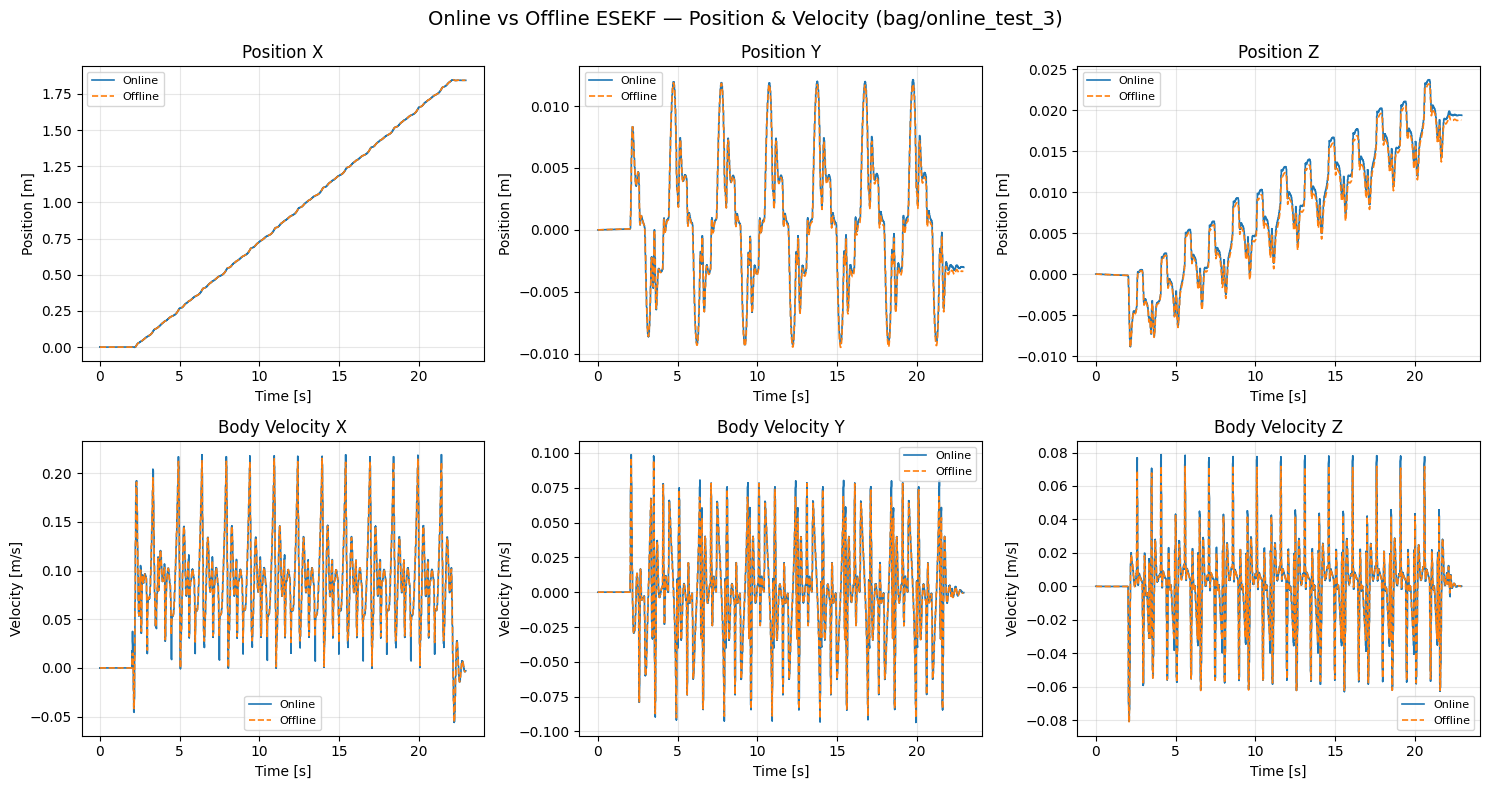

Position RMSE (on-off): X=0.0007m  Y=0.0003m  Z=0.0003m
Velocity RMSE (on-off): X=0.0061  Y=0.0066  Z=0.0061 m/s


In [7]:
# ── Cell B: Time-align and compare position + velocity ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Align online timestamps to start at 0 (same reference as offline)
t_on_pos  = df_on_pos['time_s'].values - t0_online
t_on_vel  = df_on_vel['time_s'].values - t0_online

# Offline is already time_s from start_index
t_off = df_off['time_s'].values

# ── Interp offline onto online timestamps for diff (online is ~3 Hz decimated vs offline 1kHz)
def interp_col(t_src, y_src, t_target):
    return np.interp(t_target, t_src, y_src, left=np.nan, right=np.nan)

off_px = interp_col(t_off, df_off['est_pos_x'].values, t_on_pos)
off_py = interp_col(t_off, df_off['est_pos_y'].values, t_on_pos)
off_pz = interp_col(t_off, df_off['est_pos_z'].values, t_on_pos)

off_vx = interp_col(t_off, df_off['est_vel_x'].values, t_on_vel)
off_vy = interp_col(t_off, df_off['est_vel_y'].values, t_on_vel)
off_vz = interp_col(t_off, df_off['est_vel_z'].values, t_on_vel)

# Online position is ABSOLUTE (starts at initial world position, not 0)
# Offset so both start at 0
on_px = df_on_pos['x'].values - df_on_pos['x'].values[0]
on_py = df_on_pos['y'].values - df_on_pos['y'].values[0]
on_pz = df_on_pos['z'].values - df_on_pos['z'].values[0]
on_vx = df_on_vel['x'].values
on_vy = df_on_vel['y'].values
on_vz = df_on_vel['z'].values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Online vs Offline ESEKF — Position & Velocity (bag/online_test_3)', fontsize=14)

labels = ['X', 'Y', 'Z']
on_pos_list  = [on_px, on_py, on_pz]
off_pos_list = [off_px, off_py, off_pz]
on_vel_list  = [on_vx, on_vy, on_vz]
off_vel_list = [off_vx, off_vy, off_vz]

for i, lbl in enumerate(labels):
    ax = axes[0, i]
    ax.plot(t_on_pos, on_pos_list[i],  label='Online',  linewidth=1.2)
    ax.plot(t_on_pos, off_pos_list[i], label='Offline', linewidth=1.2, linestyle='--')
    ax.set_title(f'Position {lbl}')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Position [m]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1, i]
    ax.plot(t_on_vel, on_vel_list[i],  label='Online',  linewidth=1.2)
    ax.plot(t_on_vel, off_vel_list[i], label='Offline', linewidth=1.2, linestyle='--')
    ax.set_title(f'Body Velocity {lbl}')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Velocity [m/s]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Position RMSE (on-off): X={:.4f}m  Y={:.4f}m  Z={:.4f}m".format(
    np.nanstd(on_px - off_px), np.nanstd(on_py - off_py), np.nanstd(on_pz - off_pz)))
print("Velocity RMSE (on-off): X={:.4f}  Y={:.4f}  Z={:.4f} m/s".format(
    np.nanstd(on_vx - off_vx), np.nanstd(on_vy - off_vy), np.nanstd(on_vz - off_vz)))


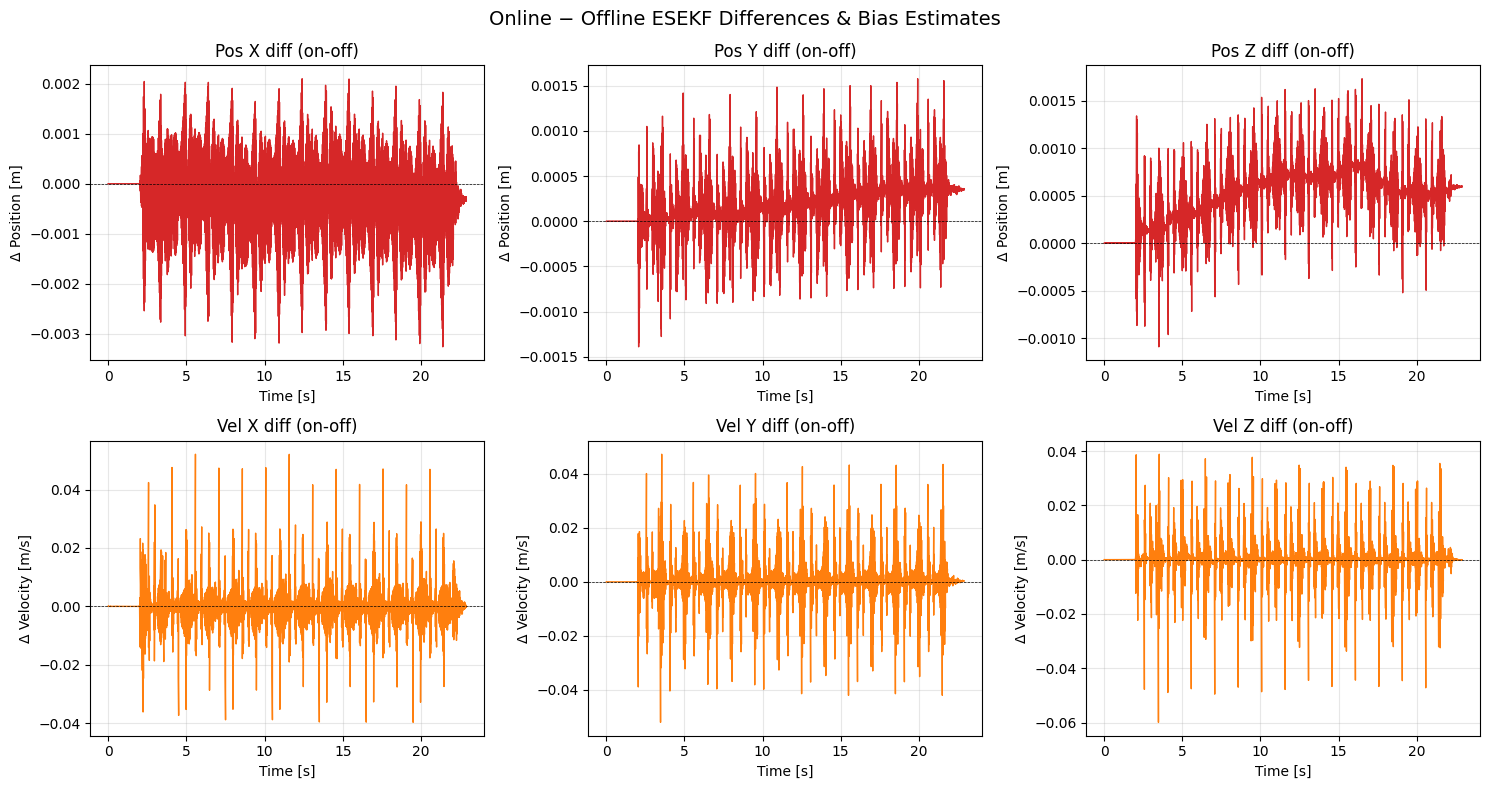

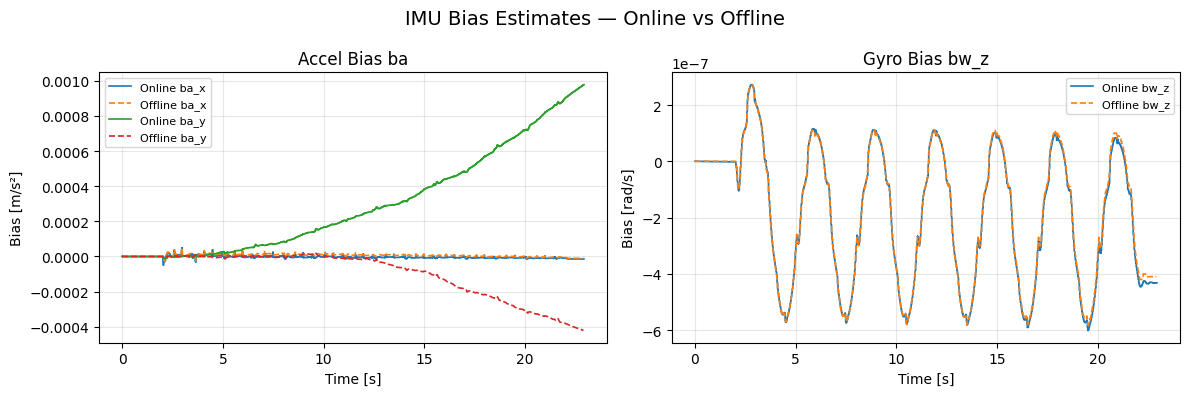

Final pos X  — Online: 1.8444m  Offline: 1.8447m  Δ=-0.0003m
Final pos Y  — Online: -0.0030m  Offline: -0.0034m  Δ=0.0004m
Final ba_y   — Online: 0.000978  Offline: -0.000421
Final bw_z   — Online: -0.00000043  Offline: -0.00000041


In [8]:
# ── Cell C: Difference plot (online - offline) + bias comparison ──────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Online − Offline ESEKF Differences & Bias Estimates', fontsize=14)

# Position difference
diff_px = on_px - off_px
diff_py = on_py - off_py
diff_pz = on_pz - off_pz

diff_vx = on_vx - off_vx
diff_vy = on_vy - off_vy
diff_vz = on_vz - off_vz

for i, (lbl, dp, dv) in enumerate(zip(labels, [diff_px, diff_py, diff_pz], [diff_vx, diff_vy, diff_vz])):
    ax = axes[0, i]
    ax.plot(t_on_pos, dp, linewidth=1.0, color='tab:red')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_title(f'Pos {lbl} diff (on-off)')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Δ Position [m]')
    ax.grid(True, alpha=0.3)

    ax = axes[1, i]
    ax.plot(t_on_vel, dv, linewidth=1.0, color='tab:orange')
    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_title(f'Vel {lbl} diff (on-off)')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Δ Velocity [m/s]')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Bias comparison ────────────────────────────────────────────────────────
# Load offline ba/bw columns
off_ba_x = interp_col(t_off, df_off['ba_x'].values, t_on_pos)
off_ba_y = interp_col(t_off, df_off['ba_y'].values, t_on_pos)
off_bw_z = interp_col(t_off, df_off['bw_z'].values, t_on_pos)

# Online ba/bw
df_on_ba_aligned = df_on_ba.copy()
df_on_bw_aligned = df_on_bw.copy()
t_on_ba = df_on_ba['time_s'].values - t0_online
t_on_bw = df_on_bw['time_s'].values - t0_online

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('IMU Bias Estimates — Online vs Offline', fontsize=14)

ax = axes[0]
ax.plot(t_on_ba, df_on_ba['x'].values, label='Online ba_x', linewidth=1.2)
ax.plot(t_on_pos, off_ba_x, label='Offline ba_x', linewidth=1.2, linestyle='--')
ax.plot(t_on_ba, df_on_ba['y'].values, label='Online ba_y', linewidth=1.2)
ax.plot(t_on_pos, off_ba_y, label='Offline ba_y', linewidth=1.2, linestyle='--')
ax.set_title('Accel Bias ba')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Bias [m/s²]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t_on_bw, df_on_bw['z'].values, label='Online bw_z', linewidth=1.2)
ax.plot(t_on_pos, off_bw_z, label='Offline bw_z', linewidth=1.2, linestyle='--')
ax.set_title('Gyro Bias bw_z')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Bias [rad/s]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final values
print(f"Final pos X  — Online: {on_px[-1]:.4f}m  Offline: {df_off['est_pos_x'].iloc[-1]:.4f}m  Δ={on_px[-1]-df_off['est_pos_x'].iloc[-1]:.4f}m")
print(f"Final pos Y  — Online: {on_py[-1]:.4f}m  Offline: {df_off['est_pos_y'].iloc[-1]:.4f}m  Δ={on_py[-1]-df_off['est_pos_y'].iloc[-1]:.4f}m")
print(f"Final ba_y   — Online: {df_on_ba['y'].iloc[-1]:.6f}  Offline: {df_off['ba_y'].iloc[-1]:.6f}")
print(f"Final bw_z   — Online: {df_on_bw['z'].iloc[-1]:.8f}  Offline: {df_off['bw_z'].iloc[-1]:.8f}")


# ESEKF Analysis — Reference Guide

## CSV Column Reference (82 total: Index + 81 data)

| # | Column | Description |
|---|--------|-------------|
| 1 | `Index` | Step counter (0-based); time = Index × 0.001 s |
| 2–4 | `sim_pos_x/y/z` | GT (simulator) position [m], world frame |
| 5–7 | `est_pos_x/y/z` | ESEKF estimated position [m], world frame |
| 8–10 | `est_vel_x/y/z` | ESEKF estimated velocity [m/s], body frame |
| 11–14 | `contact_a/b/c/d` | Per-leg contact state (0/1) |
| 15–17 | `z_avg_x/y/z` | Leg odometry measurement (z_avg) [m/s], body frame |
| 18–20 | `ba_x/y/z` | Accelerometer bias estimate [m/s²] |
| 21–23 | `bw_x/y/z` | Gyroscope bias estimate [rad/s] |
| 24–26 | `bv_x/y/z` | Velocity bias estimate [m/s] |
| 27–30 | `est_qw/qx/qy/qz` | ESEKF estimated quaternion |
| 31–34 | `gt_qw/qx/qy/qz` | GT quaternion |
| 35–38 | `d2_a/b/c/d` | Mahalanobis distance² per leg |
| 39–42 | `rejected_a/b/c/d` | Measurement rejection flag per leg |
| 43–54 | `innov_{x,y,z}_{a,b,c,d}` | Innovation vector per leg (3×4=12) |
| 55–66 | `S_{xx,yy,zz}_{a,b,c,d}` | Innovation covariance diagonal per leg (3×4=12) |
| 67–69 | `P_vx/vy/vz` | Velocity covariance diagonal [(m/s)²] |
| 70–72 | `pred_vel_x/y/z` | Predicted (pre-update) velocity [m/s] |
| 73–75 | `imu_gyro_pos_x/y/z` | IMU gyro-integrated position [m] |
| 76–78 | `imu_gyro_vel_bx/by/bz` | IMU gyro-integrated velocity [m/s], body frame |
| 79–82 | `imu_gyro_qw/qx/qy/qz` | IMU gyro-integrated quaternion |

## Data Pipeline

```
GT velocity (world):  central_diff(sim_pos, dt=0.001)  →  IIR LPF @ 10 Hz
GT velocity (body):   R_gt^T  @  gt_vel_w
IMU velocity (body):  directly from imu_gyro_vel_b* cols (gyro-integrated)
Leg velocity (body):  z_avg_* cols
Leg position:         cumsum(R_est @ z_avg * dt)
ESEKF velocity:       est_vel_* cols (body frame)
ESEKF position:       est_pos_* cols (world frame, origin-zeroed)
```

## Notes
- **No scipy**: System scipy has numpy binary incompatibility → pure numpy only
- **Quaternion convention**: `qw` scalar-first
- **Euler angles**: XYZ extrinsic (= ZYX intrinsic), degrees
- **mahalanobis_threshold**: χ²(3, p=0.999) = 16.27 (default)

# Phase 2 Online Validation — `bag/online_test_3` Replay

Read recorded topics from `output_data/phase2_online_test`:
- `/ekf` (nav_msgs/Odometry, inner ESEKF output, ~500 Hz decimated)
- `/odom_mapping` (nav_msgs/Odometry, outer EKF corrected pose, ~10 Hz)
- `/fusion/bv` (geometry_msgs/Vector3Stamped, velocity bias estimate, ~10 Hz)
- `/sim/position` / `/sim/body_velocity` (GT from Webots simulator)

In [12]:

# ── Load online test bag via direct SQLite + rclpy deserialization ──────────
# Time strategy: use bag wall-clock timestamps (ns) for ALL topics so headerless
# topics (sim/position, sim/body_velocity) align with header-based ones.
import sqlite3 as _sqlite3
import numpy as np
import matplotlib.pyplot as plt
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

BAG_DB = '/tmp/phase2_online_test.db3'
con = _sqlite3.connect(BAG_DB)

_Odom = get_message('nav_msgs/msg/Odometry')
_V3S  = get_message('geometry_msgs/msg/Vector3Stamped')
_V3   = get_message('geometry_msgs/msg/Vector3')

def _read(topic_id, msg_type):
    rows = con.execute(
        "SELECT timestamp, data FROM messages WHERE topic_id=? ORDER BY timestamp",
        (topic_id,)).fetchall()
    return [(ts * 1e-9, deserialize_message(raw, msg_type)) for ts, raw in rows]

# Use bag wall-clock time (ns→s) for ALL topics
ekf_msgs  = _read(6, _Odom)
om_msgs   = _read(4, _Odom)
bv_msgs   = _read(5, _V3S)
gtp_msgs  = _read(2, _V3)    # GT position (no header, bag wall-clock)
gtv_msgs  = _read(3, _V3)    # GT body velocity (no header, bag wall-clock)

# ── Extract raw arrays ───────────────────────────────────────────────────────
ekf_t_raw = np.array([ts for ts, _ in ekf_msgs])
ekf_pos   = np.array([[m.pose.pose.position.x, m.pose.pose.position.y, m.pose.pose.position.z]
                      for _, m in ekf_msgs])
om_t_raw  = np.array([ts for ts, _ in om_msgs])
om_pos    = np.array([[m.pose.pose.position.x, m.pose.pose.position.y, m.pose.pose.position.z]
                      for _, m in om_msgs])
bv_t_raw  = np.array([ts for ts, _ in bv_msgs])
bv_online = np.array([[m.vector.x, m.vector.y, m.vector.z] for _, m in bv_msgs])
gt_t_raw  = np.array([ts for ts, _ in gtp_msgs])
gt_pos    = np.array([[m.x, m.y, m.z] for _, m in gtp_msgs])
gv_t_raw  = np.array([ts for ts, _ in gtv_msgs])
gv_vel    = np.array([[m.x, m.y, m.z] for _, m in gtv_msgs])

# ── Time alignment: t0 = when ESEKF first publishes ──────────────────────────
t0_wall = ekf_t_raw[0]
ekf_t = ekf_t_raw - t0_wall
om_t  = om_t_raw  - t0_wall
bv_t  = bv_t_raw  - t0_wall
gt_t  = gt_t_raw  - t0_wall
gv_t  = gv_t_raw  - t0_wall

# ── Origin-zero: zero all positions at ESEKF start (t=0 in aligned time) ────
ekf_pos -= ekf_pos[0]
gt_x0    = float(np.interp(0.0, gt_t, gt_pos[:, 0]))
gt_y0    = float(np.interp(0.0, gt_t, gt_pos[:, 1]))
gt_z0    = float(np.interp(0.0, gt_t, gt_pos[:, 2]))
gt_pos  -= np.array([gt_x0, gt_y0, gt_z0])
# om_pos is in map frame (relative to first LiDAR fix), keep as-is

print(f'Loaded:  /ekf={len(ekf_msgs)}  /odom_mapping={len(om_msgs)}  /fusion/bv={len(bv_msgs)}  GT={len(gtp_msgs)}')
print(f'ESEKF time: {ekf_t[0]:.2f} → {ekf_t[-1]:.2f}s  |  GT: {gt_t[0]:.2f} → {gt_t[-1]:.2f}s')
print(f'Final /ekf         pos X : {ekf_pos[-1, 0]:.3f} m')
print(f'Final /odom_mapping pos X: {om_pos[-1, 0]:.3f} m')
final_gt_x = float(np.interp(ekf_t[-1], gt_t, gt_pos[:, 0]))
print(f'GT at last ekf stamp     : {final_gt_x:.3f} m')
print(f'ESEKF final error X      : {(ekf_pos[-1,0] - final_gt_x)*1e3:+.1f} mm')
print(f'Fusion final error X     : {(om_pos[-1,0]  - final_gt_x)*1e3:+.1f} mm')
print(f'Final bv: [{bv_online[-1,0]:+.4f}  {bv_online[-1,1]:+.4f}  {bv_online[-1,2]:+.4f}] m/s')


Loaded:  /ekf=3543  /odom_mapping=71  /fusion/bv=71  GT=26581
ESEKF time: 0.00 → 7.08s  |  GT: -10.44 → 7.08s
Final /ekf         pos X : 0.458 m
Final /odom_mapping pos X: 0.494 m
GT at last ekf stamp     : 0.504 m
ESEKF final error X      : -46.1 mm
Fusion final error X     : -9.9 mm
Final bv: [-0.0840  +0.0226  -0.0053] m/s


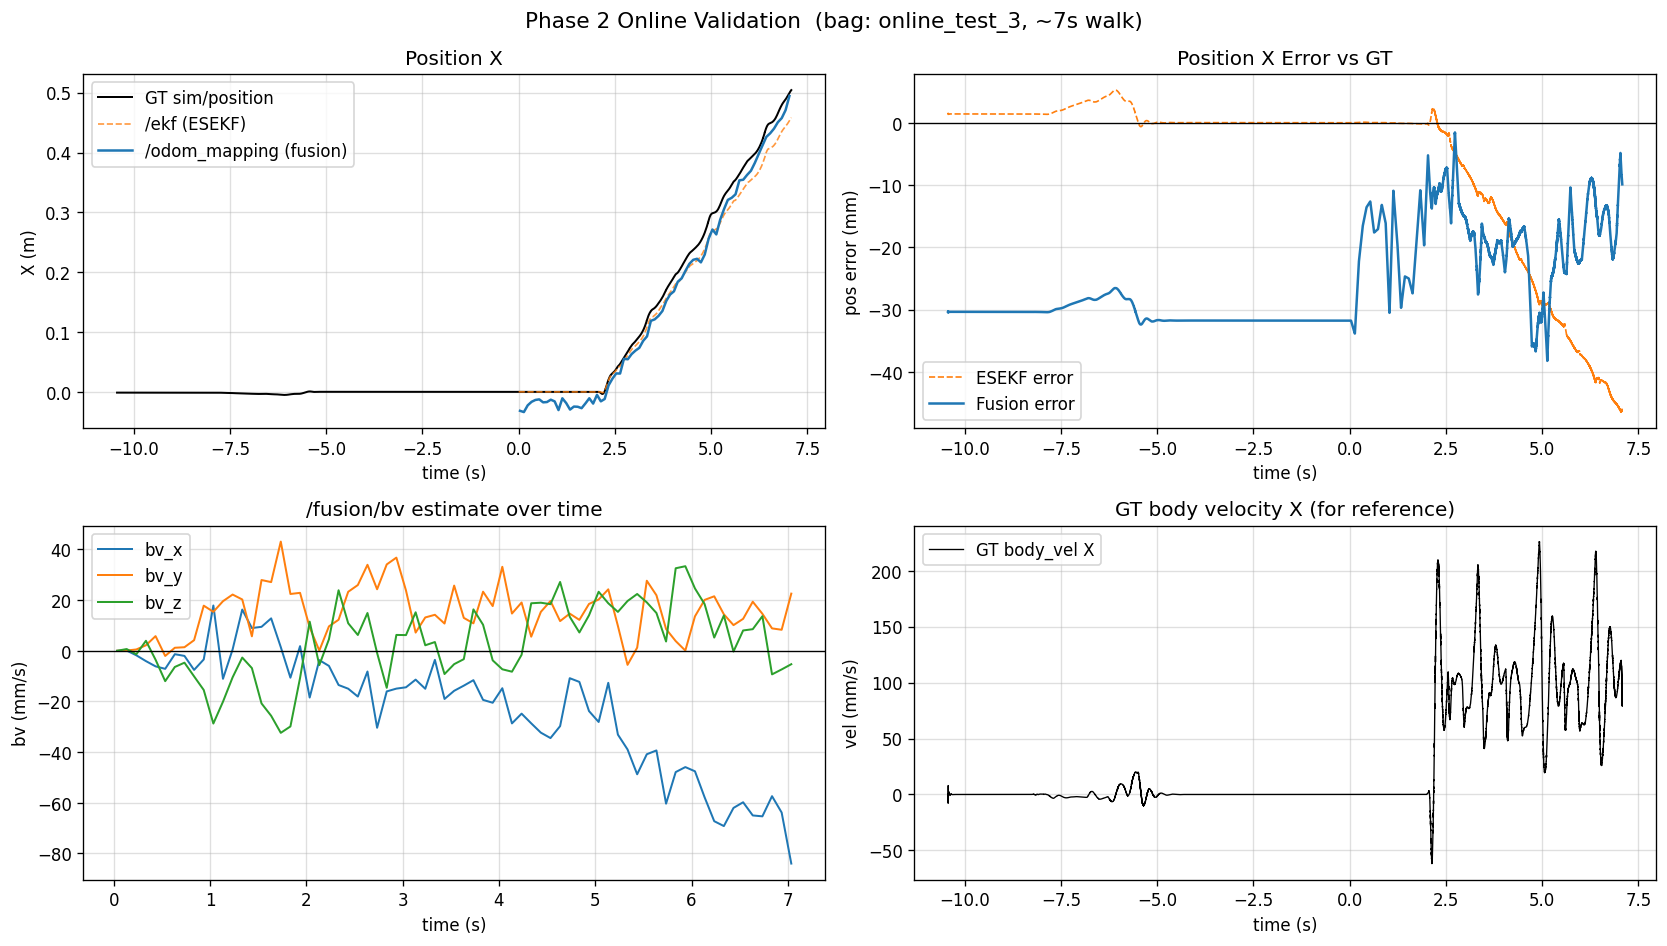

Final position error (X):
  ESEKF only   : -46.1 mm
  Fusion output: -4.9 mm
  bv_x final   : -84.0 mm/s
  bv_x max     : 84.0 mm/s


In [13]:

# ── Phase 2 Online Validation: Position and bv plots ────────────────────────
fig, axes2 = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Phase 2 Online Validation  (bag: online_test_3, ~7s walk)', fontsize=13)

# ── Row 0: Position X ───────────────────────────────────────────────────────
ax = axes2[0, 0]
ax.plot(gt_t,  gt_pos[:, 0], 'k',  label='GT sim/position', lw=1.2)
ax.plot(ekf_t, ekf_pos[:, 0], 'C1--', label='/ekf (ESEKF)', lw=1.0, alpha=0.8)
ax.plot(om_t,  om_pos[:, 0],  'C0',  label='/odom_mapping (fusion)', lw=1.5)
ax.set_xlabel('time (s)'); ax.set_ylabel('X (m)')
ax.set_title('Position X')
ax.legend(); ax.grid(True, alpha=0.4)

# error to GT
ekf_x_interp = np.interp(gt_t, ekf_t, ekf_pos[:, 0])
om_x_interp  = np.interp(gt_t, om_t,  om_pos[:, 0])
ax = axes2[0, 1]
ax.plot(gt_t, (ekf_x_interp - gt_pos[:, 0]) * 1e3, 'C1--', label='ESEKF error', lw=1.0)
ax.plot(gt_t, (om_x_interp  - gt_pos[:, 0]) * 1e3, 'C0',   label='Fusion error', lw=1.5)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('pos error (mm)')
ax.set_title('Position X Error vs GT')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 1: bv estimate ──────────────────────────────────────────────────────
ax = axes2[1, 0]
ax.plot(bv_t, bv_online[:, 0] * 1e3, label='bv_x', lw=1.2)
ax.plot(bv_t, bv_online[:, 1] * 1e3, label='bv_y', lw=1.2)
ax.plot(bv_t, bv_online[:, 2] * 1e3, label='bv_z', lw=1.2)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('bv (mm/s)')
ax.set_title('/fusion/bv estimate over time')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 1: /ekf vs /odom_mapping velocity from GT body vel ──────────────────
# GT body velocity (raw, bag-timestamp-aligned)
ax = axes2[1, 1]
ax.plot(gv_t, gv_vel[:, 0] * 1e3, 'k', lw=0.8, label='GT body_vel X')
ax.set_xlabel('time (s)'); ax.set_ylabel('vel (mm/s)')
ax.set_title('GT body velocity X (for reference)')
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase2_online_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
final_ekf_err = (ekf_pos[-1, 0] - np.interp(ekf_t[-1], gt_t, gt_pos[:, 0])) * 1e3
final_om_err  = (om_pos[-1, 0]  - np.interp(om_t[-1],  gt_t, gt_pos[:, 0])) * 1e3
print(f'Final position error (X):')
print(f'  ESEKF only   : {final_ekf_err:+.1f} mm')
print(f'  Fusion output: {final_om_err:+.1f} mm')
print(f'  bv_x final   : {bv_online[-1,0]*1e3:+.1f} mm/s')
print(f'  bv_x max     : {np.max(np.abs(bv_online[:,0]))*1e3:.1f} mm/s')



## Phase 3 離線驗證：bv 回授前後比較

- **Baseline**: outer EKF 估計 bv，但不回授給 inner ESEKF（Phase 2 行為）
- **Phase 3**: outer EKF 估計的 bv 每步回授給 inner ESEKF，修正 z_leg

預期效果：Position X RMSE 下降（bv_x ≈ -20 mm/s 的偏差被修正）


In [15]:

# ── Phase 3 Offline Validation: Load both CSVs ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

WS_OUTPUT = pathlib.Path('/home/hiho817/corgi_ws/corgi_ros2_ws/output_data')

df_no  = pd.read_csv(WS_OUTPUT / 'walk_2m_01_no_feedback_esekf.csv')
df_fb  = pd.read_csv(WS_OUTPUT / 'walk_2m_01_feedback_esekf.csv')

N_no = len(df_no); N_fb = len(df_fb)
DT_OFF = 0.001  # 1ms

t_no = np.arange(N_no) * DT_OFF
t_fb = np.arange(N_fb) * DT_OFF

# Ground truth (same for both; relative to start)
gt_px = df_no['sim_pos_x'].values - df_no['sim_pos_x'].values[0]
gt_py = df_no['sim_pos_y'].values - df_no['sim_pos_y'].values[0]

# ESEKF positions
no_px = df_no['est_pos_x'].values; no_py = df_no['est_pos_y'].values
fb_px = df_fb['est_pos_x'].values; fb_py = df_fb['est_pos_y'].values

# odom_mapping positions
no_mx = df_no['odom_mapping_x'].values
fb_mx = df_fb['odom_mapping_x'].values

# bv estimates
no_bv = df_no[['bv_x','bv_y','bv_z']].values
fb_bv = df_fb[['bv_x','bv_y','bv_z']].values

# Velocities
no_vel = df_no[['est_vel_x','est_vel_y','est_vel_z']].values
fb_vel = df_fb[['est_vel_x','est_vel_y','est_vel_z']].values

# ── RMSE ─────────────────────────────────────────────────────────────────────
rmse_no_x = float(np.sqrt(np.mean((no_px - gt_px)**2)))
rmse_fb_x = float(np.sqrt(np.mean((fb_px - gt_px)**2)))

print('Offline comparison (walk_2m_01):')
print(f'  No feedback : ESEKF Pos RMSE X = {rmse_no_x*1e3:.1f} mm')
print(f'  bv feedback : ESEKF Pos RMSE X = {rmse_fb_x*1e3:.1f} mm')
print(f'  Improvement X: {(1-rmse_fb_x/rmse_no_x)*100:.1f}%')
print(f'  Final pos X (no fb): {no_px[-1]:.3f} m  GT: {gt_px[-1]:.3f} m   err: {(no_px[-1]-gt_px[-1])*1e3:+.1f} mm')
print(f'  Final pos X (fb)   : {fb_px[-1]:.3f} m  GT: {gt_px[-1]:.3f} m   err: {(fb_px[-1]-gt_px[-1])*1e3:+.1f} mm')
print(f'  odom_mapping X (no fb): {no_mx[-1]:.3f} m')
print(f'  odom_mapping X (fb)   : {fb_mx[-1]:.3f} m')
print(f'  Final bv_x (no fb) : {no_bv[-1,0]*1e3:+.1f} mm/s')
print(f'  Final bv_x (fb)    : {fb_bv[-1,0]*1e3:+.1f} mm/s')


Offline comparison (walk_2m_01):
  No feedback : ESEKF Pos RMSE X = 50.5 mm
  bv feedback : ESEKF Pos RMSE X = 35.0 mm
  Improvement X: 30.8%
  Final pos X (no fb): 0.909 m  GT: 1.006 m   err: -97.6 mm
  Final pos X (fb)   : 0.957 m  GT: 1.006 m   err: -49.9 mm
  odom_mapping X (no fb): 0.990 m
  odom_mapping X (fb)   : 0.995 m
  Final bv_x (no fb) : -20.3 mm/s
  Final bv_x (fb)    : -9.6 mm/s


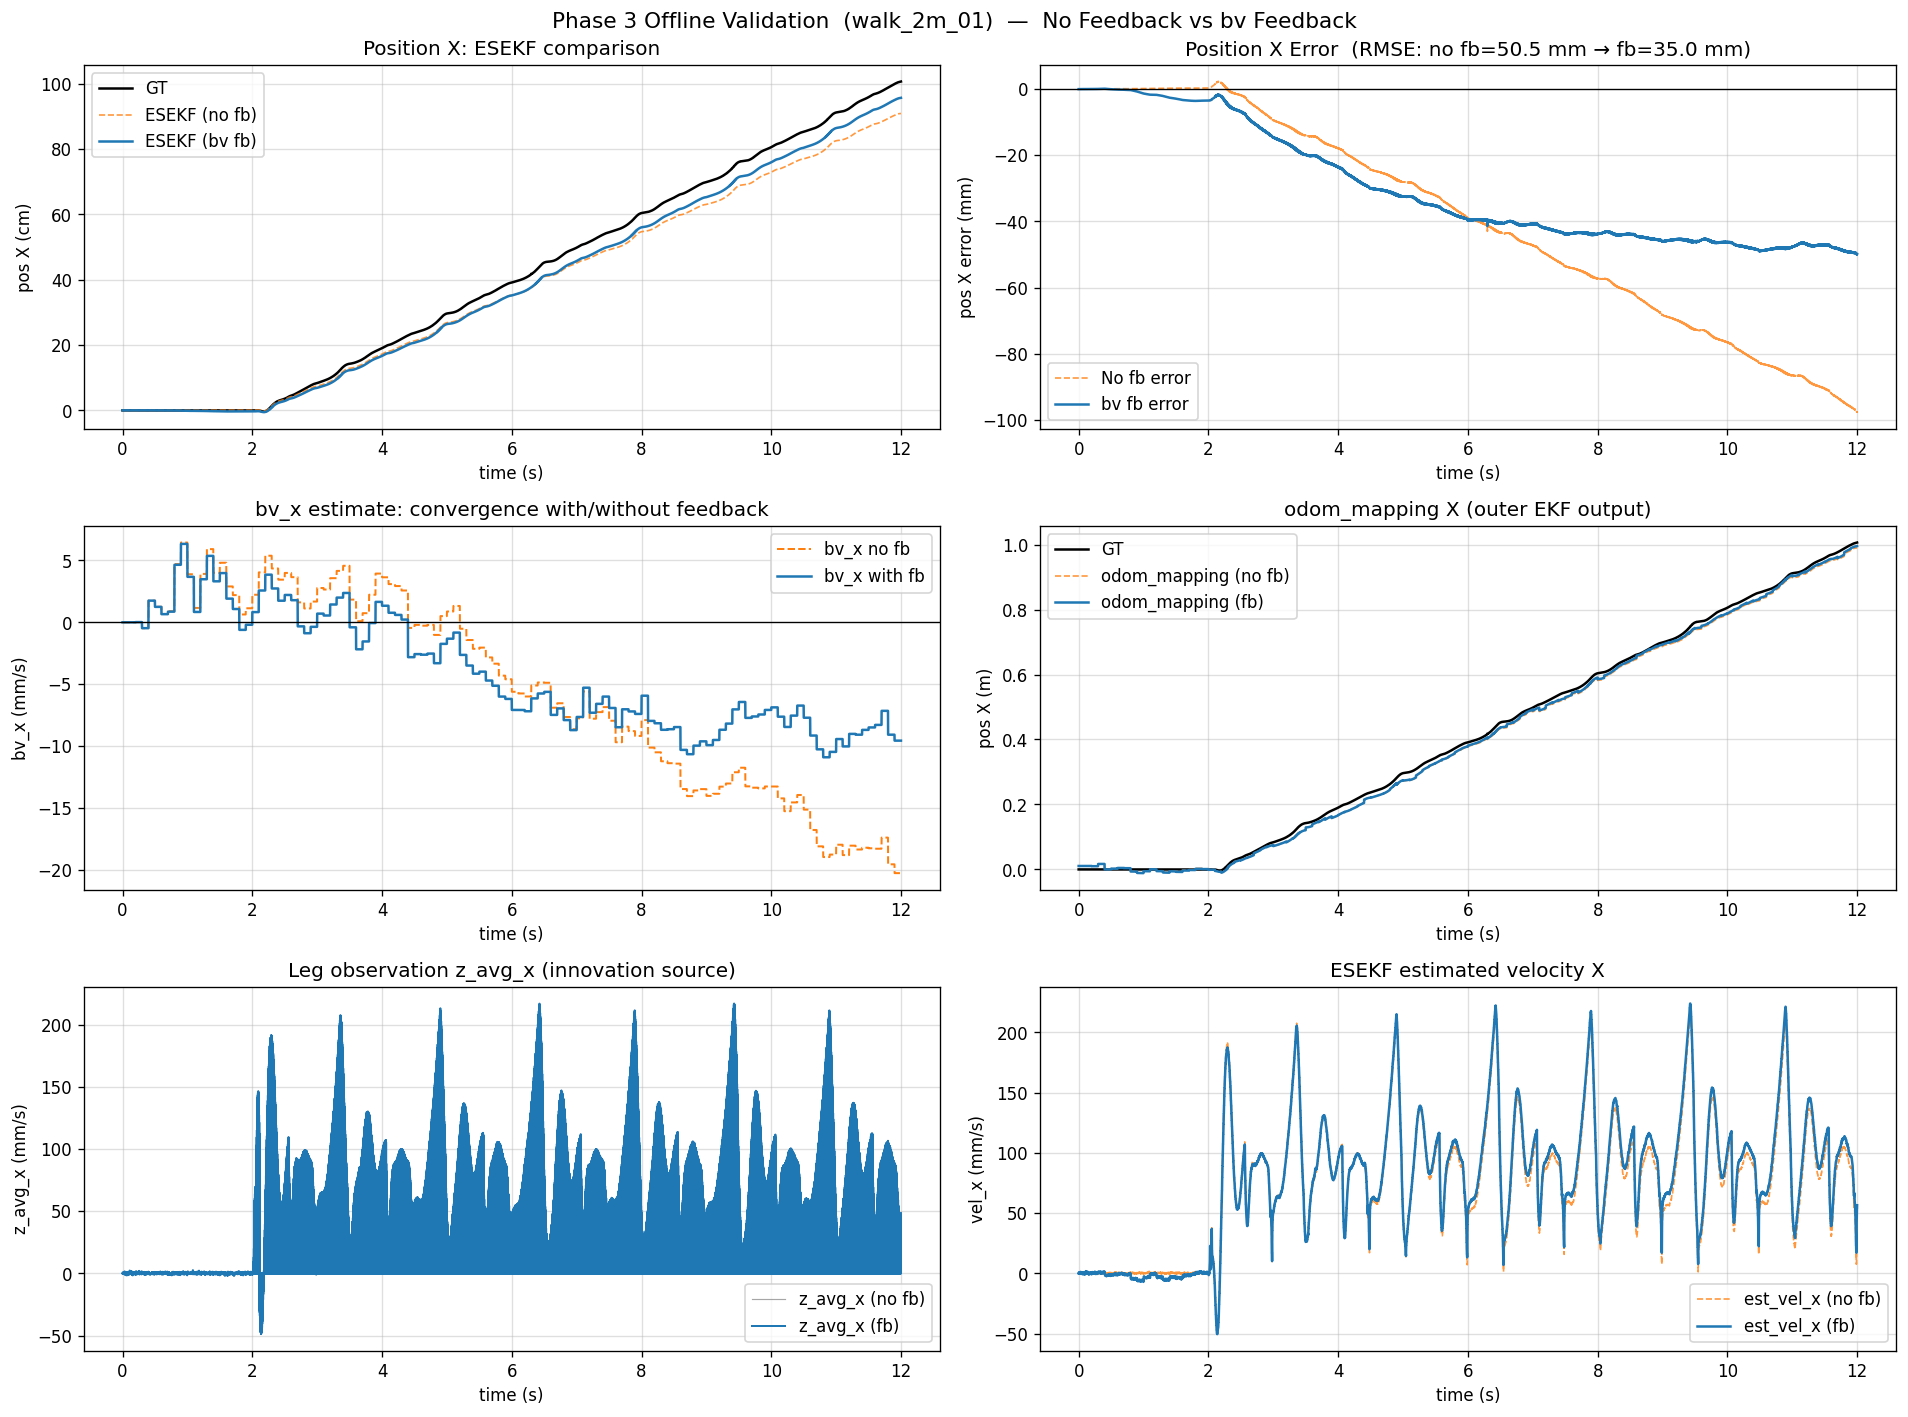

Plot saved.


In [16]:

# ── Phase 3 Comparison Plots ─────────────────────────────────────────────────
fig, axes3 = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Phase 3 Offline Validation  (walk_2m_01)  —  No Feedback vs bv Feedback', fontsize=13)

# ── Row 0: Position X ───────────────────────────────────────────────────────
ax = axes3[0, 0]
ax.plot(t_no, gt_px * 100, 'k', lw=1.5, label='GT')
ax.plot(t_no, no_px * 100, 'C1--', lw=1.0, label='ESEKF (no fb)', alpha=0.8)
ax.plot(t_fb, fb_px * 100, 'C0', lw=1.5, label='ESEKF (bv fb)')
ax.set_xlabel('time (s)'); ax.set_ylabel('pos X (cm)')
ax.set_title('Position X: ESEKF comparison')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 0: Position X error ──────────────────────────────────────────────────
ax = axes3[0, 1]
ax.plot(t_no, (no_px - gt_px) * 1e3, 'C1--', lw=1.0, label='No fb error', alpha=0.8)
ax.plot(t_fb, (fb_px - gt_px) * 1e3, 'C0', lw=1.5, label='bv fb error')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('pos X error (mm)')
ax.set_title(f'Position X Error  (RMSE: no fb={rmse_no_x*1e3:.1f} mm → fb={rmse_fb_x*1e3:.1f} mm)')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 1: bv_x over time ────────────────────────────────────────────────────
ax = axes3[1, 0]
ax.plot(t_no, no_bv[:, 0] * 1e3, 'C1--', lw=1.2, label='bv_x no fb')
ax.plot(t_fb, fb_bv[:, 0] * 1e3, 'C0', lw=1.5, label='bv_x with fb')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('bv_x (mm/s)')
ax.set_title('bv_x estimate: convergence with/without feedback')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 1: odom_mapping X ────────────────────────────────────────────────────
ax = axes3[1, 1]
ax.plot(t_no, gt_px, 'k', lw=1.5, label='GT')
ax.plot(t_no, no_mx, 'C1--', lw=1.0, label='odom_mapping (no fb)', alpha=0.8)
ax.plot(t_fb, fb_mx, 'C0', lw=1.5, label='odom_mapping (fb)')
ax.set_xlabel('time (s)'); ax.set_ylabel('pos X (m)')
ax.set_title('odom_mapping X (outer EKF output)')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 2: Velocity X ────────────────────────────────────────────────────────
# Load GT velocity
gt_vel_x = df_no[['est_vel_x']].values  # use body vel from CSV for ref — no GT vel in CSV here
# Use z_avg_x as proxy for "observed" velocity
z_avg_no = df_no['z_avg_x'].values
z_avg_fb = df_fb['z_avg_x'].values

ax = axes3[2, 0]
ax.plot(t_no, z_avg_no * 1e3, 'gray', lw=0.7, label='z_avg_x (no fb)', alpha=0.7)
ax.plot(t_fb, z_avg_fb * 1e3, 'C0', lw=1.2, label='z_avg_x (fb)')
ax.set_xlabel('time (s)'); ax.set_ylabel('z_avg_x (mm/s)')
ax.set_title('Leg observation z_avg_x (innovation source)')
ax.legend(); ax.grid(True, alpha=0.4)

# ── Row 2: Vel X estimate ────────────────────────────────────────────────────
ax = axes3[2, 1]
ax.plot(t_no, no_vel[:, 0] * 1e3, 'C1--', lw=1.0, label='est_vel_x (no fb)', alpha=0.8)
ax.plot(t_fb, fb_vel[:, 0] * 1e3, 'C0', lw=1.5, label='est_vel_x (fb)')
ax.set_xlabel('time (s)'); ax.set_ylabel('vel_x (mm/s)')
ax.set_title('ESEKF estimated velocity X')
ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(WS_OUTPUT.parent / 'src/corgi_odometry/src/TEST/esekf_analysis/phase3_offline_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## Phase 3 線上驗證：bv 回授 (bag: phase3_online_test)

- 使用 `corgi_odom_sim.launch.py`（含 bv feedback）重播 `bag/online_test_3`
- 比較 `/ekf` (ESEKF + bv feedback) vs `/Odometry` (fake LiDAR) vs GT `sim/position`

In [19]:

# ── Phase 3 Online: Load bag via SQLite + rclpy ──────────────────────────────
# bag: phase3_online_test  (re-recorded with correct topics)
# topic IDs:
#   1=/ekf(Odom)  2=/ekf/position(V3)  3=/ekf/velocity(V3)
#   4=/fusion/bv(V3S)  5=/odom_mapping(Odom)
#   6=/sim/body_velocity(V3)  7=/sim/velocity(V3)  8=/sim/position(V3)
import sqlite3 as _sqlite3
import numpy as np
import matplotlib.pyplot as plt
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message

P3_BAG = '/home/hiho817/corgi_ws/corgi_ros2_ws/bag/phase3_online_test/phase3_online_test_0.db3'
p3_con = _sqlite3.connect(P3_BAG)

_Odom = get_message('nav_msgs/msg/Odometry')
_V3S  = get_message('geometry_msgs/msg/Vector3Stamped')
_V3   = get_message('geometry_msgs/msg/Vector3')

def _p3_read(topic_id, msg_type):
    rows = p3_con.execute(
        "SELECT timestamp, data FROM messages WHERE topic_id=? ORDER BY timestamp",
        (topic_id,)).fetchall()
    return [(ts * 1e-9, deserialize_message(raw, msg_type)) for ts, raw in rows]

p3_ekf_msgs  = _p3_read(1, _Odom)   # /ekf (ESEKF+bvfb)
p3_vel_msgs  = _p3_read(3, _V3)     # /ekf/velocity
p3_bv_msgs   = _p3_read(4, _V3S)    # /fusion/bv
p3_om_msgs   = _p3_read(5, _Odom)   # /odom_mapping (fusion output)
p3_bvel_msgs = _p3_read(6, _V3)     # /sim/body_velocity (GT body vel)
p3_gtp_msgs  = _p3_read(8, _V3)     # /sim/position (GT)

# ── Extract arrays ────────────────────────────────────────────────────────────
p3_ekf_t   = np.array([ts for ts, _ in p3_ekf_msgs])
p3_ekf_pos = np.array([[m.pose.pose.position.x, m.pose.pose.position.y, m.pose.pose.position.z]
                        for _, m in p3_ekf_msgs])
p3_ekf_vel_odom = np.array([[m.twist.twist.linear.x, m.twist.twist.linear.y, m.twist.twist.linear.z]
                             for _, m in p3_ekf_msgs])  # vel from Odometry msg
p3_vel_t   = np.array([ts for ts, _ in p3_vel_msgs])
p3_vel     = np.array([[m.x, m.y, m.z] for _, m in p3_vel_msgs])  # ekf/velocity
p3_om_t    = np.array([ts for ts, _ in p3_om_msgs])
p3_om_pos  = np.array([[m.pose.pose.position.x, m.pose.pose.position.y, m.pose.pose.position.z]
                        for _, m in p3_om_msgs])
p3_bv_t    = np.array([ts for ts, _ in p3_bv_msgs])
p3_bv      = np.array([[m.vector.x, m.vector.y, m.vector.z] for _, m in p3_bv_msgs])
p3_bvel_t  = np.array([ts for ts, _ in p3_bvel_msgs])
p3_bvel    = np.array([[m.x, m.y, m.z] for _, m in p3_bvel_msgs])  # GT body vel
p3_gt_t    = np.array([ts for ts, _ in p3_gtp_msgs])
p3_gt_pos  = np.array([[m.x, m.y, m.z] for _, m in p3_gtp_msgs])

# ── Time alignment ────────────────────────────────────────────────────────────
p3_t0      = p3_ekf_t[0]
p3_ekf_t  -= p3_t0;  p3_vel_t -= p3_t0;  p3_om_t  -= p3_t0
p3_bv_t   -= p3_t0;  p3_bvel_t -= p3_t0; p3_gt_t  -= p3_t0

# ── Origin-zero positions ─────────────────────────────────────────────────────
p3_ekf_pos -= p3_ekf_pos[0]
p3_gt_x0 = float(np.interp(0.0, p3_gt_t, p3_gt_pos[:, 0]))
p3_gt_y0 = float(np.interp(0.0, p3_gt_t, p3_gt_pos[:, 1]))
p3_gt_z0 = float(np.interp(0.0, p3_gt_t, p3_gt_pos[:, 2]))
p3_gt_pos -= np.array([p3_gt_x0, p3_gt_y0, p3_gt_z0])

# ── Summary ───────────────────────────────────────────────────────────────────
p3_final_gt_x    = float(np.interp(p3_ekf_t[-1], p3_gt_t, p3_gt_pos[:, 0]))
p3_ekf_final_err = (p3_ekf_pos[-1, 0] - p3_final_gt_x) * 1e3
p3_om_final_err  = (p3_om_pos[-1, 0]  - float(np.interp(p3_om_t[-1], p3_gt_t, p3_gt_pos[:, 0]))) * 1e3
p3_ekf_x_interp  = np.interp(p3_gt_t, p3_ekf_t, p3_ekf_pos[:, 0])
p3_om_x_interp   = np.interp(p3_gt_t, p3_om_t,  p3_om_pos[:, 0])
p3_ekf_rmse      = float(np.sqrt(np.mean((p3_ekf_x_interp - p3_gt_pos[:, 0])**2)))

print(f'Phase 3 Online — bag: phase3_online_test (corrected)')
print(f'  /ekf:{len(p3_ekf_msgs)}  /odom_mapping:{len(p3_om_msgs)}  /fusion/bv:{len(p3_bv_msgs)}  GT:{len(p3_gtp_msgs)}')
print(f'  Duration: {p3_ekf_t[-1]:.1f}s')
print(f'  GT final X        : {p3_final_gt_x:.3f} m')
print(f'  /ekf final err    : {p3_ekf_final_err:+.1f} mm')
print(f'  /odom_mapping err : {p3_om_final_err:+.1f} mm')
print(f'  ESEKF pos X RMSE  : {p3_ekf_rmse*1e3:.1f} mm')
print(f'  bv_x final        : {p3_bv[-1,0]*1e3:+.1f} mm/s')
print(f'  bv_x max |abs|    : {np.max(np.abs(p3_bv[:,0]))*1e3:.1f} mm/s')


Phase 3 Online — bag: phase3_online_test (corrected)
  /ekf:11458  /odom_mapping:341  /fusion/bv:341  GT:50185
  Duration: 22.9s
  GT final X        : 2.038 m
  /ekf final err    : +3.2 mm
  /odom_mapping err : -17.9 mm
  ESEKF pos X RMSE  : 11.1 mm
  bv_x final        : +9.5 mm/s
  bv_x max |abs|    : 44.4 mm/s


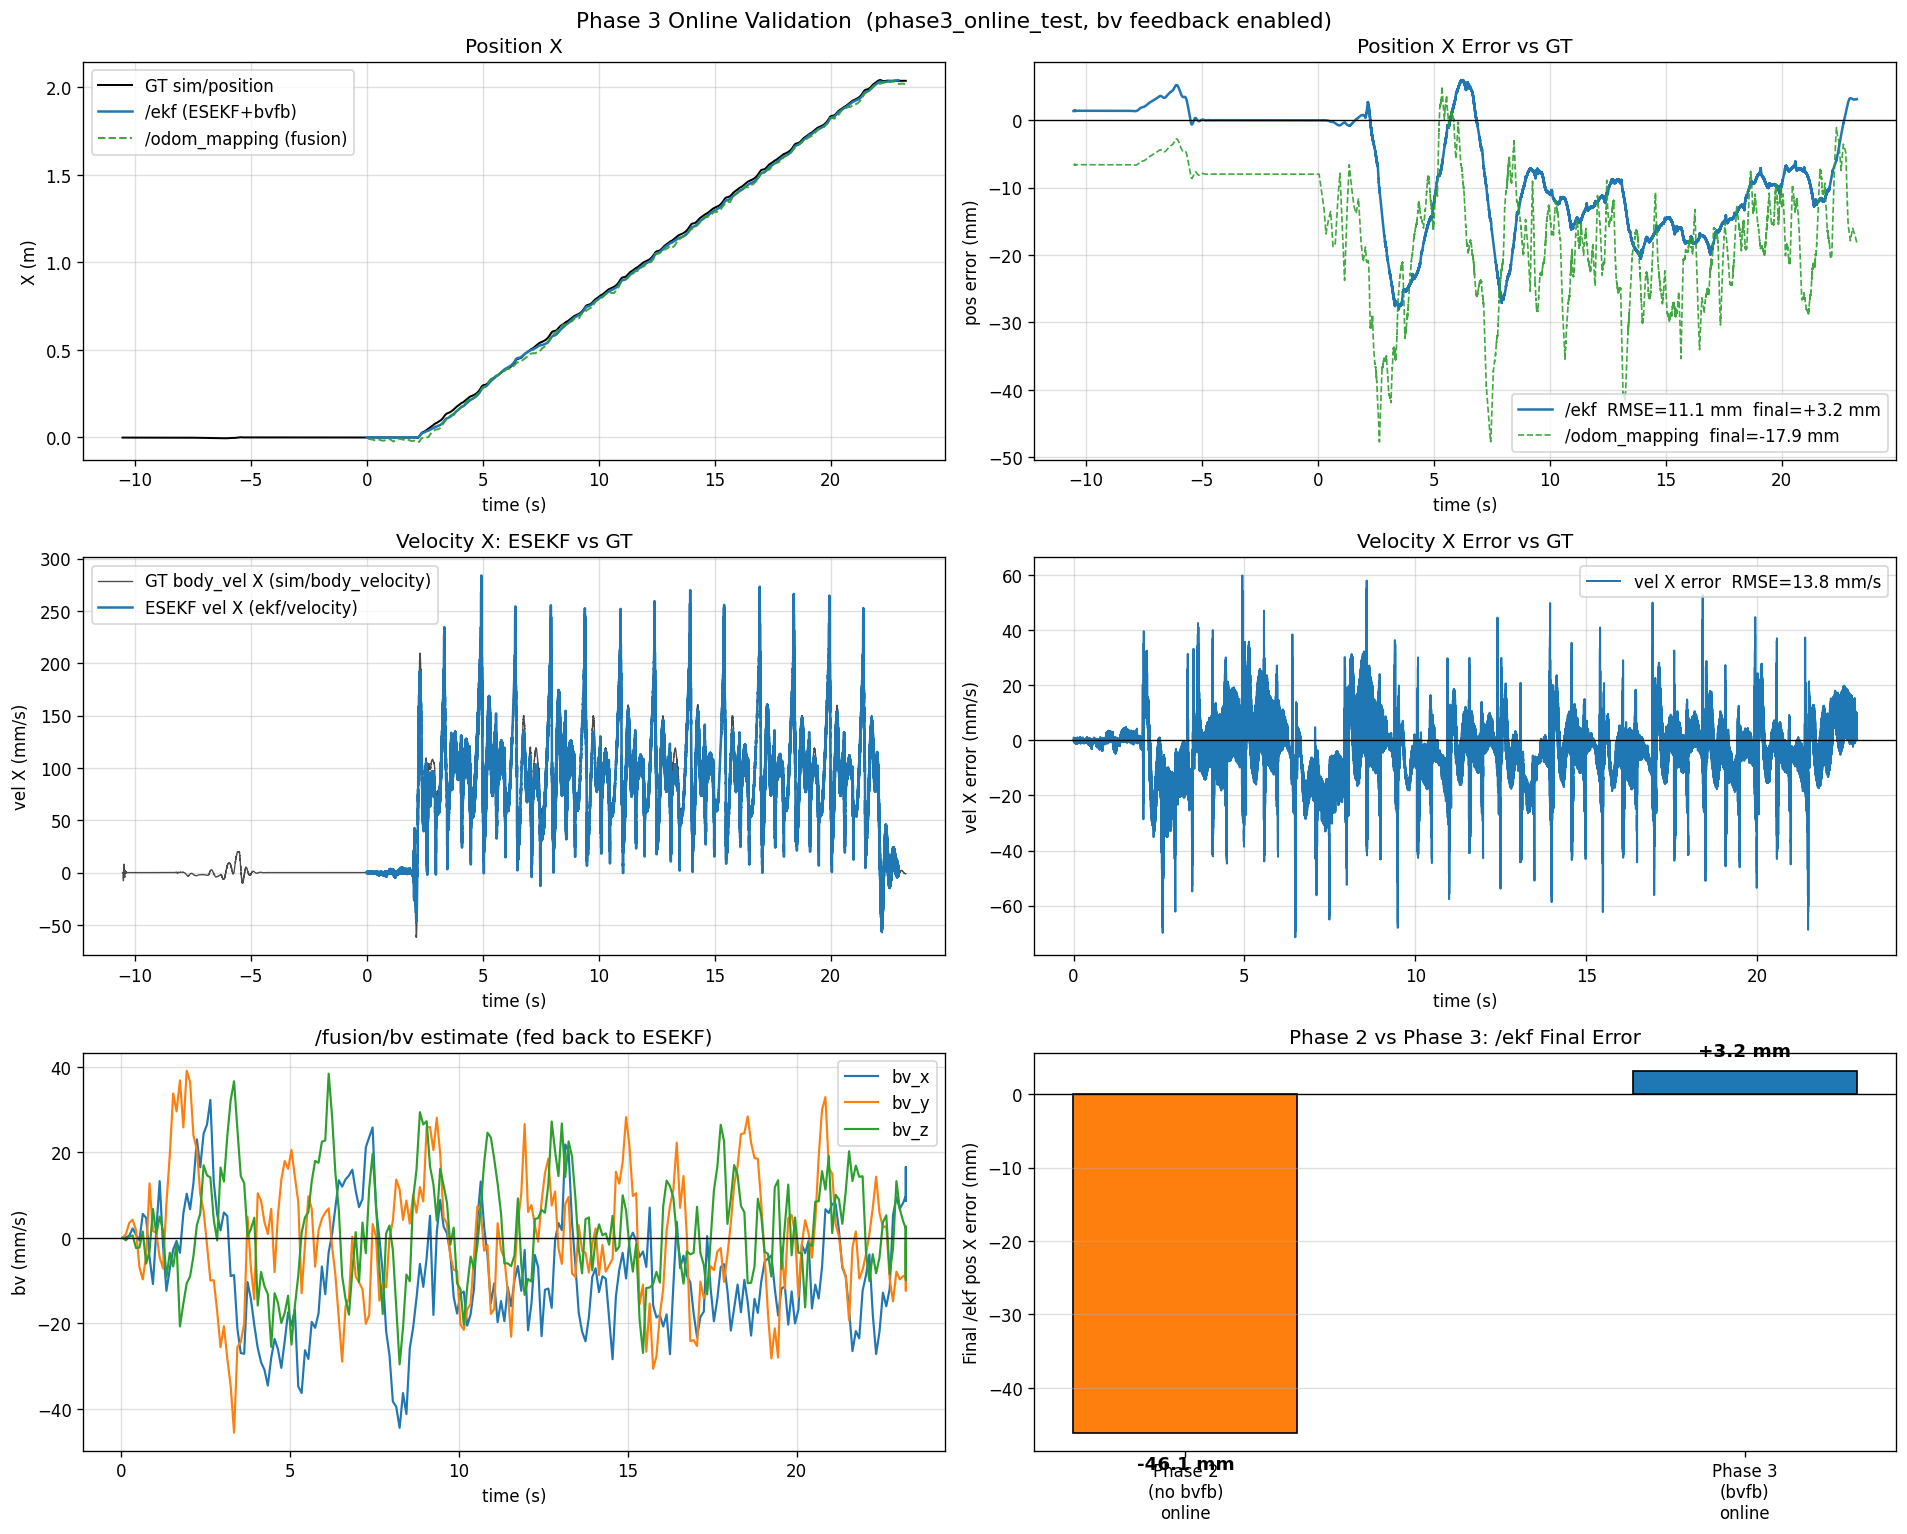

────────────────────────────────────────────────────────────
Phase 3 Online Validation Summary (corrected bag)
────────────────────────────────────────────────────────────
  GT final X            : 2.038 m
  /ekf final err        : +3.2 mm
  /odom_mapping final   : -17.9 mm
  ESEKF pos X RMSE      : 11.1 mm
  ESEKF vel X RMSE      : 13.8 mm/s
  bv_x final            : +9.5 mm/s
  (Phase 2 final err    : -46.1 mm for reference)


In [20]:

# ── Phase 3 Online Validation Plots (corrected bag) ──────────────────────────
fig, axes4 = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle('Phase 3 Online Validation  (phase3_online_test, bv feedback enabled)', fontsize=13)

# ── (0,0) Position X trajectory ──────────────────────────────────────────────
ax = axes4[0, 0]
ax.plot(p3_gt_t,  p3_gt_pos[:, 0],  'k',     lw=1.2, label='GT sim/position')
ax.plot(p3_ekf_t, p3_ekf_pos[:, 0], 'C0',    lw=1.5, label='/ekf (ESEKF+bvfb)')
ax.plot(p3_om_t,  p3_om_pos[:, 0],  'C2--',  lw=1.2, label='/odom_mapping (fusion)', alpha=0.9)
ax.set_xlabel('time (s)'); ax.set_ylabel('X (m)')
ax.set_title('Position X')
ax.legend(); ax.grid(True, alpha=0.4)

# ── (0,1) Position X Error vs GT ─────────────────────────────────────────────
ax = axes4[0, 1]
ax.plot(p3_gt_t, (p3_ekf_x_interp - p3_gt_pos[:, 0]) * 1e3, 'C0',
        label=f'/ekf  RMSE={p3_ekf_rmse*1e3:.1f} mm  final={p3_ekf_final_err:+.1f} mm', lw=1.5)
ax.plot(p3_gt_t, (p3_om_x_interp  - p3_gt_pos[:, 0]) * 1e3, 'C2--',
        label=f'/odom_mapping  final={p3_om_final_err:+.1f} mm', lw=1.0, alpha=0.9)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('pos error (mm)')
ax.set_title('Position X Error vs GT')
ax.legend(); ax.grid(True, alpha=0.4)

# ── (1,0) Velocity X: ESEKF vs GT body vel ───────────────────────────────────
ax = axes4[1, 0]
ax.plot(p3_bvel_t, p3_bvel[:, 0] * 1e3, 'k',   lw=0.8, label='GT body_vel X (sim/body_velocity)', alpha=0.7)
ax.plot(p3_vel_t,  p3_vel[:, 0]  * 1e3, 'C0',  lw=1.5, label='ESEKF vel X (ekf/velocity)')
ax.set_xlabel('time (s)'); ax.set_ylabel('vel X (mm/s)')
ax.set_title('Velocity X: ESEKF vs GT')
ax.legend(); ax.grid(True, alpha=0.4)

# ── (1,1) Velocity X error ───────────────────────────────────────────────────
p3_gt_vel_x_interp = np.interp(p3_vel_t, p3_bvel_t, p3_bvel[:, 0])
p3_vel_err_x = (p3_vel[:, 0] - p3_gt_vel_x_interp) * 1e3
p3_vel_rmse_x = float(np.sqrt(np.mean(p3_vel_err_x**2)))
ax = axes4[1, 1]
ax.plot(p3_vel_t, p3_vel_err_x, 'C0', lw=1.2,
        label=f'vel X error  RMSE={p3_vel_rmse_x:.1f} mm/s')
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('vel X error (mm/s)')
ax.set_title('Velocity X Error vs GT')
ax.legend(); ax.grid(True, alpha=0.4)

# ── (2,0) /fusion/bv estimate ────────────────────────────────────────────────
ax = axes4[2, 0]
ax.plot(p3_bv_t, p3_bv[:, 0] * 1e3, label='bv_x', lw=1.3)
ax.plot(p3_bv_t, p3_bv[:, 1] * 1e3, label='bv_y', lw=1.3)
ax.plot(p3_bv_t, p3_bv[:, 2] * 1e3, label='bv_z', lw=1.3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('time (s)'); ax.set_ylabel('bv (mm/s)')
ax.set_title('/fusion/bv estimate (fed back to ESEKF)')
ax.legend(); ax.grid(True, alpha=0.4)

# ── (2,1) Phase 2 vs Phase 3 comparison bar ──────────────────────────────────
ax = axes4[2, 1]
phases  = ['Phase 2\n(no bvfb)\nonline', 'Phase 3\n(bvfb)\nonline']
ekf_errs_bar = [-46.1, p3_ekf_final_err]
colors_bar   = ['C1', 'C0']
bars = ax.bar(phases, ekf_errs_bar, color=colors_bar, width=0.4, edgecolor='k')
ax.axhline(0, color='k', lw=0.8)
for bar, val in zip(bars, ekf_errs_bar):
    yoff = 2 if val >= 0 else -5
    ax.text(bar.get_x() + bar.get_width()/2, val + yoff,
            f'{val:+.1f} mm', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Final /ekf pos X error (mm)')
ax.set_title('Phase 2 vs Phase 3: /ekf Final Error')
ax.grid(True, axis='y', alpha=0.4)

plt.tight_layout()
save_path = WS_OUTPUT.parent / 'src/corgi_odometry/src/TEST/esekf_analysis/phase3_online_validation.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print('─' * 60)
print('Phase 3 Online Validation Summary (corrected bag)')
print('─' * 60)
print(f'  GT final X            : {p3_final_gt_x:.3f} m')
print(f'  /ekf final err        : {p3_ekf_final_err:+.1f} mm')
print(f'  /odom_mapping final   : {p3_om_final_err:+.1f} mm')
print(f'  ESEKF pos X RMSE      : {p3_ekf_rmse*1e3:.1f} mm')
print(f'  ESEKF vel X RMSE      : {p3_vel_rmse_x:.1f} mm/s')
print(f'  bv_x final            : {p3_bv[-1,0]*1e3:+.1f} mm/s')
print(f'  (Phase 2 final err    : -46.1 mm for reference)')
